In [2]:
 # Install required packages
!pip -q install numpy pandas matplotlib seaborn scikit-learn scipy joblib

^C


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.optimize import differential_evolution

import joblib

In [4]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [5]:
PROJECT_NAME = "ML_RFOpt"

PROJECT_DIR = Path(PROJECT_NAME)

DIRECTORIES = [
    "data",
    "data/raw",
    "data/processed",
    "models",
    "figures",
    "results",
    "logs"
]

for directory in DIRECTORIES:
    path = PROJECT_DIR / directory
    path.mkdir(parents=True, exist_ok=True)

print("Project structure created successfully.")

for path in PROJECT_DIR.rglob("*"):
    if path.is_dir():
        print("📁", path)

Project structure created successfully.
📁 ML_RFOpt\data
📁 ML_RFOpt\figures
📁 ML_RFOpt\final_results
📁 ML_RFOpt\logs
📁 ML_RFOpt\models
📁 ML_RFOpt\results
📁 ML_RFOpt\data\processed
📁 ML_RFOpt\data\raw
📁 ML_RFOpt\figures\publication
📁 ML_RFOpt\final_results\models
📁 ML_RFOpt\final_results\publication_figures
📁 ML_RFOpt\final_results\tables


In [6]:


# Indoor environment dimensions
ROOM_WIDTH = 20.0       
ROOM_HEIGHT = 20.0      

GRID_RESOLUTION = 0.25  

# RF parameters
FREQUENCY_MHZ = 2400    
TRANSMIT_POWER_DBM = 20 
ANTENNA_GAIN_DBI = 2.0

# Receiver parameters
RECEIVER_GAIN_DBI = 0.0

MIN_DISTANCE = 0.5

print("Room size:", ROOM_WIDTH, "m ×", ROOM_HEIGHT, "m")
print("Frequency:", FREQUENCY_MHZ, "MHz")
print("Transmit power:", TRANSMIT_POWER_DBM, "dBm")
print("Grid resolution:", GRID_RESOLUTION, "m")

Room size: 20.0 m × 20.0 m
Frequency: 2400 MHz
Transmit power: 20 dBm
Grid resolution: 0.25 m


In [ ]:
print("ML-RFOpt Environment Check")

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("\nProject directory:")
print(PROJECT_DIR.resolve())

In [9]:
# SYNTHETIC INDOOR ENVIRONMENT

OBSTACLES = [
    (4.0, 4.0, 8.0, 6.0),
    (11.0, 4.0, 16.0, 6.0),
    (5.0, 11.0, 8.0, 16.0),
    (12.0, 12.0, 17.0, 15.0)
]

print("Number of obstacles:", len(OBSTACLES))

for i, obstacle in enumerate(OBSTACLES, start=1):
    print(f"Obstacle {i}: {obstacle}")

Number of obstacles: 4
Obstacle 1: (4.0, 4.0, 8.0, 6.0)
Obstacle 2: (11.0, 4.0, 16.0, 6.0)
Obstacle 3: (5.0, 11.0, 8.0, 16.0)
Obstacle 4: (12.0, 12.0, 17.0, 15.0)


In [ ]:

# CREATE 2D INDOOR GRID
x_coordinates = np.arange(
    0,
    ROOM_WIDTH + GRID_RESOLUTION,
    GRID_RESOLUTION
)

y_coordinates = np.arange(
    0,
    ROOM_HEIGHT + GRID_RESOLUTION,
    GRID_RESOLUTION
)

X, Y = np.meshgrid(
    x_coordinates,
    y_coordinates
)

print("Grid shape:", X.shape)
print("Number of grid points:", X.size)

In [11]:
# OBSTACLE MASK

obstacle_mask = np.zeros_like(X, dtype=bool)

for x_min, y_min, x_max, y_max in OBSTACLES:

    current_obstacle = (
        (X >= x_min) &
        (X <= x_max) &
        (Y >= y_min) &
        (Y <= y_max)
    )

    obstacle_mask = obstacle_mask | current_obstacle

print("Obstacle grid points:", obstacle_mask.sum())
print(
    "Free-space grid points:",
    (~obstacle_mask).sum()
)

Obstacle grid points: 888
Free-space grid points: 5673


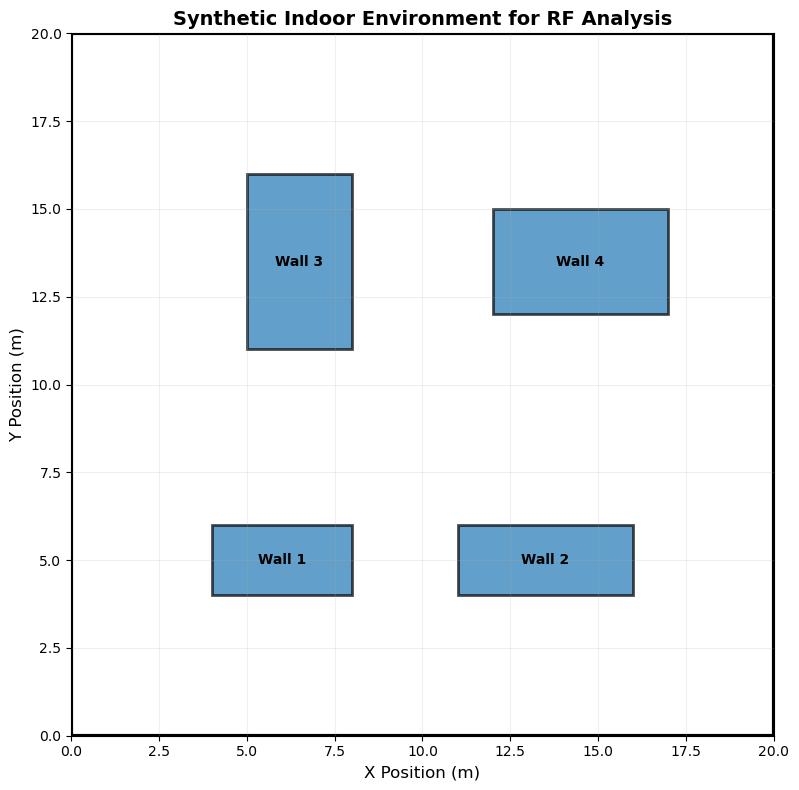

Figure saved to:
ML_RFOpt\figures\synthetic_indoor_environment.png


In [12]:
# VISUALIZE INDOOR ENVIRONMENT

fig, ax = plt.subplots(figsize=(9, 8))

# Plot room boundary
ax.set_xlim(0, ROOM_WIDTH)
ax.set_ylim(0, ROOM_HEIGHT)

# Plot obstacles
for i, (x_min, y_min, x_max, y_max) in enumerate(
    OBSTACLES,
    start=1
):

    width = x_max - x_min
    height = y_max - y_min

    rectangle = plt.Rectangle(
        (x_min, y_min),
        width,
        height,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    ax.add_patch(rectangle)

    ax.text(
        x_min + width / 2,
        y_min + height / 2,
        f"Wall {i}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Room boundary
room_boundary = plt.Rectangle(
    (0, 0),
    ROOM_WIDTH,
    ROOM_HEIGHT,
    fill=False,
    edgecolor="black",
    linewidth=3
)

ax.add_patch(room_boundary)

ax.set_xlabel("X Position (m)", fontsize=12)
ax.set_ylabel("Y Position (m)", fontsize=12)

ax.set_title(
    "Synthetic Indoor Environment for RF Analysis",
    fontsize=14,
    fontweight="bold"
)

ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.tight_layout()

# Save figure
environment_figure = (
    PROJECT_DIR /
    "figures" /
    "synthetic_indoor_environment.png"
)

plt.savefig(
    environment_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(environment_figure)

In [13]:
# INITIAL ANTENNA POSITION

ANTENNA_X = 2.0
ANTENNA_Y = 2.0

print("Initial antenna position:")
print(f"X = {ANTENNA_X} m")
print(f"Y = {ANTENNA_Y} m")

Initial antenna position:
X = 2.0 m
Y = 2.0 m


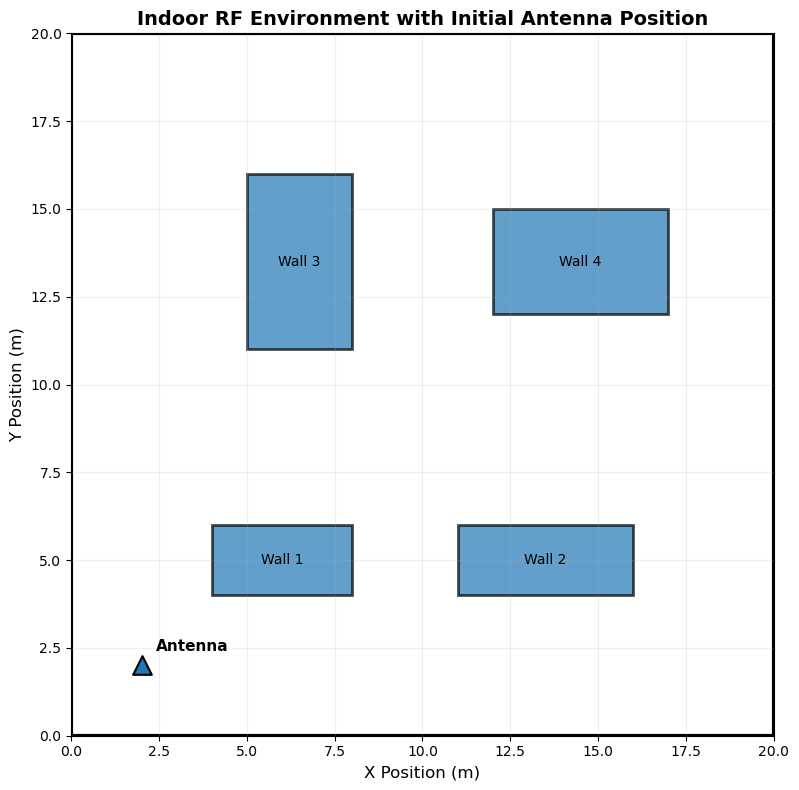

Figure saved to:
ML_RFOpt\figures\environment_with_antenna.png


In [14]:
# ENVIRONMENT WITH ANTENNA

fig, ax = plt.subplots(figsize=(9, 8))

ax.set_xlim(0, ROOM_WIDTH)
ax.set_ylim(0, ROOM_HEIGHT)

# Plot obstacles
for i, (x_min, y_min, x_max, y_max) in enumerate(
    OBSTACLES,
    start=1
):

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    ax.add_patch(rectangle)

    ax.text(
        (x_min + x_max) / 2,
        (y_min + y_max) / 2,
        f"Wall {i}",
        ha="center",
        va="center",
        fontsize=10
    )

# Room boundary
ax.add_patch(
    plt.Rectangle(
        (0, 0),
        ROOM_WIDTH,
        ROOM_HEIGHT,
        fill=False,
        edgecolor="black",
        linewidth=3
    )
)

# Antenna
ax.scatter(
    ANTENNA_X,
    ANTENNA_Y,
    s=180,
    marker="^",
    edgecolor="black",
    linewidth=1.5,
    zorder=10
)

ax.text(
    ANTENNA_X + 0.4,
    ANTENNA_Y + 0.4,
    "Antenna",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel("X Position (m)", fontsize=12)
ax.set_ylabel("Y Position (m)", fontsize=12)

ax.set_title(
    "Indoor RF Environment with Initial Antenna Position",
    fontsize=14,
    fontweight="bold"
)

ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.tight_layout()

antenna_figure = (
    PROJECT_DIR /
    "figures" /
    "environment_with_antenna.png"
)

plt.savefig(
    antenna_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(antenna_figure)

In [15]:
# SAVE ENVIRONMENT CONFIGURATION

import json

environment_config = {
    "room_width_m": ROOM_WIDTH,
    "room_height_m": ROOM_HEIGHT,
    "grid_resolution_m": GRID_RESOLUTION,
    "frequency_mhz": FREQUENCY_MHZ,
    "transmit_power_dbm": TRANSMIT_POWER_DBM,
    "antenna_gain_dbi": ANTENNA_GAIN_DBI,
    "receiver_gain_dbi": RECEIVER_GAIN_DBI,
    "initial_antenna_x": ANTENNA_X,
    "initial_antenna_y": ANTENNA_Y,
    "obstacles": OBSTACLES
}

config_path = PROJECT_DIR / "environment_config.json"

with open(config_path, "w") as file:
    json.dump(
        environment_config,
        file,
        indent=4
    )

print("Environment configuration saved:")
print(config_path)

Environment configuration saved:
ML_RFOpt\environment_config.json


In [17]:
#print("ML-RFOpt — ENVIRONMENT CHECK")

#print(f"Room: {ROOM_WIDTH} m × {ROOM_HEIGHT} m")
#print(f"Grid resolution: {GRID_RESOLUTION} m")
#print(f"Grid points: {X.size}")
#print(f"Obstacles: {len(OBSTACLES)}")
#print(f"Initial antenna: ({ANTENNA_X}, {ANTENNA_Y})")
#print(f"Frequency: {FREQUENCY_MHZ} MHz")
#print(f"Transmit power: {TRANSMIT_POWER_DBM} dBm")

#print("\nProject files:")

#for path in PROJECT_DIR.rglob("*"):
   # if path.is_file():
      #  print("  ✓", path)


In [19]:

# RF PROPAGATION PARAMETERS

REFERENCE_DISTANCE = 1.0  

# Indoor path-loss exponent
PATH_LOSS_EXPONENT = 2.2
WALL_LOSS_DB = 8.0
MIN_RSSI_DBM = -120.0

print("RF propagation parameters")
print("Frequency:", FREQUENCY_MHZ, "MHz")
print("Transmit power:", TRANSMIT_POWER_DBM, "dBm")
print("Transmitter gain:", ANTENNA_GAIN_DBI, "dBi")
print("Receiver gain:", RECEIVER_GAIN_DBI, "dBi")
print("Path-loss exponent:", PATH_LOSS_EXPONENT)
print("Wall loss:", WALL_LOSS_DB, "dB")

RF propagation parameters
Frequency: 2400 MHz
Transmit power: 20 dBm
Transmitter gain: 2.0 dBi
Receiver gain: 0.0 dBi
Path-loss exponent: 2.2
Wall loss: 8.0 dB


In [20]:
# FREE-SPACE REFERENCE PATH LOSS

SPEED_OF_LIGHT = 299792458.0  # m/s

frequency_hz = FREQUENCY_MHZ * 1e6

wavelength = SPEED_OF_LIGHT / frequency_hz

reference_path_loss_db = (
    20 * np.log10(
        (4 * np.pi * REFERENCE_DISTANCE) /
        wavelength
    )
)

print("Frequency:", FREQUENCY_MHZ, "MHz")
print("Wavelength:", round(wavelength, 4), "m")
print(
    "Reference path loss:",
    round(reference_path_loss_db, 3),
    "dB"
)

Frequency: 2400 MHz
Wavelength: 0.1249 m
Reference path loss: 40.052 dB


In [21]:
# PATH-LOSS FUNCTION

def calculate_path_loss(
    distance,
    reference_distance=REFERENCE_DISTANCE,
    reference_loss_db=reference_path_loss_db,
    path_loss_exponent=PATH_LOSS_EXPONENT
):
    """
    Calculate indoor path loss using the
    log-distance path-loss model.
    """

    distance = np.maximum(
        np.asarray(distance),
        reference_distance
    )

    path_loss = (
        reference_loss_db
        + 10
        * path_loss_exponent
        * np.log10(
            distance / reference_distance
        )
    )

    return path_loss

In [22]:
# TEST PATH-LOSS MODEL

test_distances = np.array([
    1.0,
    2.0,
    5.0,
    10.0,
    15.0,
    20.0
])

test_path_loss = calculate_path_loss(test_distances)

path_loss_table = pd.DataFrame({
    "Distance_m": test_distances,
    "Path_Loss_dB": test_path_loss
})

display(path_loss_table)

,Distance_m,Path_Loss_dB
0,1.0,40.052008
1,2.0,46.674668
2,5.0,55.429348
3,10.0,62.052008
4,15.0,65.926016
5,20.0,68.674668


In [23]:
# LINE SEGMENT - RECTANGLE INTERSECTION

def orientation(p, q, r):
    """
    Determine orientation of three points.
    """

    value = (
        (q[1] - p[1]) * (r[0] - q[0])
        -
        (q[0] - p[0]) * (r[1] - q[1])
    )

    if abs(value) < 1e-12:
        return 0

    if value > 0:
        return 1

    return 2


def on_segment(p, q, r):
    """
    Check whether q lies on segment pr.
    """

    return (
        min(p[0], r[0]) <= q[0] <= max(p[0], r[0])
        and
        min(p[1], r[1]) <= q[1] <= max(p[1], r[1])
    )


def segments_intersect(p1, q1, p2, q2):
    """
    Check whether two line segments intersect.
    """

    o1 = orientation(p1, q1, p2)
    o2 = orientation(p1, q1, q2)
    o3 = orientation(p2, q2, p1)
    o4 = orientation(p2, q2, q1)

    if o1 != o2 and o3 != o4:
        return True

    if o1 == 0 and on_segment(p1, p2, q1):
        return True

    if o2 == 0 and on_segment(p1, q2, q1):
        return True

    if o3 == 0 and on_segment(p2, p1, q2):
        return True

    if o4 == 0 and on_segment(p2, q1, q2):
        return True

    return False

In [24]:
# COUNT OBSTACLE INTERSECTIONS

def count_obstacle_crossings(
    antenna_position,
    receiver_position,
    obstacles=OBSTACLES
):
    """
    Count the number of obstacles crossed by the
    direct propagation path.
    """

    x1, y1 = antenna_position
    x2, y2 = receiver_position

    crossings = 0

    for obstacle in obstacles:

        x_min, y_min, x_max, y_max = obstacle

        # Rectangle corners
        bottom_left = (x_min, y_min)
        bottom_right = (x_max, y_min)
        top_right = (x_max, y_max)
        top_left = (x_min, y_max)

        rectangle_edges = [
            (bottom_left, bottom_right),
            (bottom_right, top_right),
            (top_right, top_left),
            (top_left, bottom_left)
        ]

        path_start = (x1, y1)
        path_end = (x2, y2)

        intersects = any(
            segments_intersect(
                path_start,
                path_end,
                edge_start,
                edge_end
            )
            for edge_start, edge_end in rectangle_edges
        )

        # If receiver is inside the obstacle, count it
        receiver_inside = (
            x_min <= x2 <= x_max
            and
            y_min <= y2 <= y_max
        )

        if intersects or receiver_inside:
            crossings += 1

    return crossings

In [25]:
# TEST OBSTACLE CROSSING

antenna_test = (ANTENNA_X, ANTENNA_Y)

test_points = [
    (3.0, 3.0),
    (6.0, 5.0),
    (10.0, 10.0),
    (15.0, 5.0),
    (18.0, 18.0)
]

for point in test_points:

    crossings = count_obstacle_crossings(
        antenna_test,
        point
    )

    print(
        f"Antenna {antenna_test} → "
        f"Receiver {point}: "
        f"{crossings} obstacle(s)"
    )

Antenna (2.0, 2.0) → Receiver (3.0, 3.0): 0 obstacle(s)
Antenna (2.0, 2.0) → Receiver (6.0, 5.0): 1 obstacle(s)
Antenna (2.0, 2.0) → Receiver (10.0, 10.0): 1 obstacle(s)
Antenna (2.0, 2.0) → Receiver (15.0, 5.0): 1 obstacle(s)
Antenna (2.0, 2.0) → Receiver (18.0, 18.0): 2 obstacle(s)


In [26]:
# RSSI CALCULATION

def calculate_rssi(
    antenna_position,
    receiver_position,
    transmit_power_dbm=TRANSMIT_POWER_DBM,
    transmitter_gain_dbi=ANTENNA_GAIN_DBI,
    receiver_gain_dbi=RECEIVER_GAIN_DBI,
    wall_loss_db=WALL_LOSS_DB
):
    """
    Calculate received signal strength (RSSI)
    for a receiver position.
    """

    antenna_x, antenna_y = antenna_position
    receiver_x, receiver_y = receiver_position

    # Distance
    distance = np.sqrt(
        (receiver_x - antenna_x) ** 2
        +
        (receiver_y - antenna_y) ** 2
    )

    # Avoid zero distance
    distance = max(
        distance,
        REFERENCE_DISTANCE
    )

    # Path loss
    path_loss = calculate_path_loss(distance)

    # Number of obstacle crossings
    obstacle_count = count_obstacle_crossings(
        antenna_position,
        receiver_position
    )

    # Additional attenuation
    obstacle_loss = obstacle_count * wall_loss_db

    # Received signal strength
    rssi = (
        transmit_power_dbm
        + transmitter_gain_dbi
        + receiver_gain_dbi
        - path_loss
        - obstacle_loss
    )

    # Lower bound
    rssi = max(
        rssi,
        MIN_RSSI_DBM
    )

    return rssi, distance, obstacle_count

In [27]:
# TEST RSSI CALCULATION

test_receiver = (10.0, 10.0)

rssi, distance, obstacles_crossed = calculate_rssi(
    (ANTENNA_X, ANTENNA_Y),
    test_receiver
)

print("Receiver position:", test_receiver)
print("Distance:", round(distance, 3), "m")
print("Obstacles crossed:", obstacles_crossed)
print("RSSI:", round(rssi, 3), "dBm")

Receiver position: (10.0, 10.0)
Distance: 11.314 m
Obstacles crossed: 1
RSSI: -49.231 dBm


In [28]:
# GENERATE RF MAP

rssi_map = np.full_like(
    X,
    MIN_RSSI_DBM,
    dtype=float
)

distance_map = np.zeros_like(
    X,
    dtype=float
)

obstacle_count_map = np.zeros_like(
    X,
    dtype=int
)

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        
        if obstacle_mask[row, col]:
            continue

        rssi, distance, obstacle_count = calculate_rssi(
            (ANTENNA_X, ANTENNA_Y),
            (receiver_x, receiver_y)
        )

        rssi_map[row, col] = rssi
        distance_map[row, col] = distance
        obstacle_count_map[row, col] = obstacle_count

print("RF map generated.")
print("Minimum RSSI:", np.min(rssi_map))
print("Maximum RSSI:", np.max(rssi_map))

RF map generated.
Minimum RSSI: -120.0
Maximum RSSI: -18.052008056115497


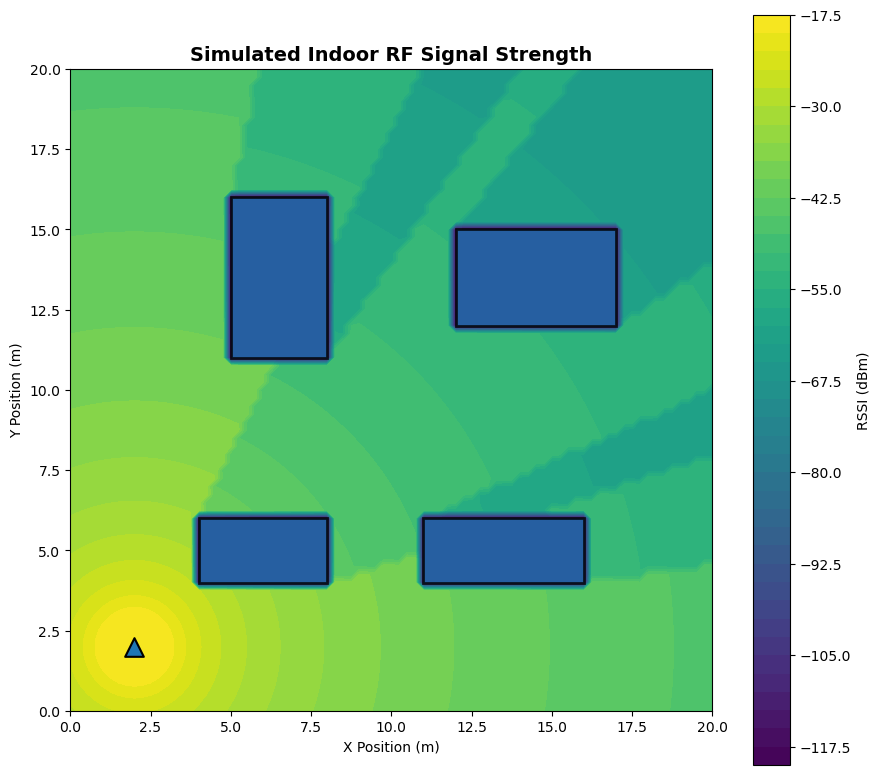

RF map saved to:
ML_RFOpt\figures\rf_signal_strength_map.png


In [29]:
# RF SIGNAL STRENGTH MAP

fig, ax = plt.subplots(figsize=(9, 8))

rf_plot = ax.contourf(
    X,
    Y,
    rssi_map,
    levels=40,
    cmap="viridis"
)

# Obstacles
for i, (x_min, y_min, x_max, y_max) in enumerate(
    OBSTACLES,
    start=1
):

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.8
    )

    ax.add_patch(rectangle)

# Antenna
ax.scatter(
    ANTENNA_X,
    ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5,
    zorder=10
)

ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")

ax.set_title(
    "Simulated Indoor RF Signal Strength",
    fontsize=14,
    fontweight="bold"
)

ax.set_aspect("equal")

colorbar = plt.colorbar(rf_plot, ax=ax)
colorbar.set_label("RSSI (dBm)")

plt.tight_layout()

rf_map_path = (
    PROJECT_DIR /
    "figures" /
    "rf_signal_strength_map.png"
)

plt.savefig(
    rf_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("RF map saved to:")
print(rf_map_path)

In [30]:

# GENERATE RF DATASET

dataset_records = []

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]


        if obstacle_mask[row, col]:
            continue

        rssi, distance, obstacle_count = calculate_rssi(
            (ANTENNA_X, ANTENNA_Y),
            (receiver_x, receiver_y)
        )

        dataset_records.append({
            "receiver_x_m": receiver_x,
            "receiver_y_m": receiver_y,
            "antenna_x_m": ANTENNA_X,
            "antenna_y_m": ANTENNA_Y,
            "distance_m": distance,
            "frequency_mhz": FREQUENCY_MHZ,
            "transmit_power_dbm": TRANSMIT_POWER_DBM,
            "antenna_gain_dbi": ANTENNA_GAIN_DBI,
            "obstacle_count": obstacle_count,
            "rssi_dbm": rssi
        })

rf_dataset = pd.DataFrame(dataset_records)

print("Dataset generated successfully.")
print("Dataset shape:", rf_dataset.shape)

Dataset generated successfully.
Dataset shape: (5673, 10)


In [31]:

# INSPECT DATASET

print("\nFirst 10 samples:")
display(rf_dataset.head(10))

print("\nDataset information:")
print(rf_dataset.info())

print("\nMissing values:")
print(rf_dataset.isnull().sum())


First 10 samples:


,receiver_x_m,receiver_y_m,antenna_x_m,antenna_y_m,distance_m,frequency_mhz,transmit_power_dbm,antenna_gain_dbi,obstacle_count,rssi_dbm
0,0.00,0.0,2.0,2.0,2.828427,2400,20,2.0,0,-27.985998
1,0.25,0.0,2.0,2.0,2.657536,2400,20,2.0,0,-27.390551
2,0.50,0.0,2.0,2.0,2.500000,2400,20,2.0,0,-26.806688
3,0.75,0.0,2.0,2.0,2.358495,2400,20,2.0,0,-26.249978
4,1.00,0.0,2.0,2.0,2.236068,2400,20,2.0,0,-25.740678
5,1.25,0.0,2.0,2.0,2.136001,2400,20,2.0,0,-25.303240
6,1.50,0.0,2.0,2.0,2.061553,2400,20,2.0,0,-24.964286
7,1.75,0.0,2.0,2.0,2.015564,2400,20,2.0,0,-24.748735
8,2.00,0.0,2.0,2.0,2.000000,2400,20,2.0,0,-24.674668
9,2.25,0.0,2.0,2.0,2.015564,2400,20,2.0,0,-24.748735



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5673 entries, 0 to 5672
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   receiver_x_m        5673 non-null   float64
 1   receiver_y_m        5673 non-null   float64
 2   antenna_x_m         5673 non-null   float64
 3   antenna_y_m         5673 non-null   float64
 4   distance_m          5673 non-null   float64
 5   frequency_mhz       5673 non-null   int64  
 6   transmit_power_dbm  5673 non-null   int64  
 7   antenna_gain_dbi    5673 non-null   float64
 8   obstacle_count      5673 non-null   int64  
 9   rssi_dbm            5673 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 443.3 KB
None

Missing values:
receiver_x_m          0
receiver_y_m          0
antenna_x_m           0
antenna_y_m           0
distance_m            0
frequency_mhz         0
transmit_power_dbm    0
antenna_gain_dbi      0
obstacle_count   

In [32]:

# DATASET STATISTICS

print("RF Dataset Statistics")

display(
    rf_dataset.describe().T
)

RF Dataset Statistics


,count,mean,std,min,25%,50%,75%,max
receiver_x_m,5673.0,9.943152,6.070029,0.000000,4.250000,10.000000,15.500000,20.000000
receiver_y_m,5673.0,9.964569,6.054450,0.000000,4.500000,9.750000,15.750000,20.000000
antenna_x_m,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
antenna_y_m,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
distance_m,5673.0,12.925918,5.739996,1.000000,8.551316,13.729530,17.338541,25.455844
frequency_mhz,5673.0,2400.000000,0.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
transmit_power_dbm,5673.0,20.000000,0.000000,20.000000,20.000000,20.000000,20.000000,20.000000
antenna_gain_dbi,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
obstacle_count,5673.0,0.719901,0.764369,0.000000,0.000000,1.000000,1.000000,2.000000
rssi_dbm,5673.0,-46.759638,10.873056,-64.979333,-53.738440,-45.854223,-40.007010,-18.052008


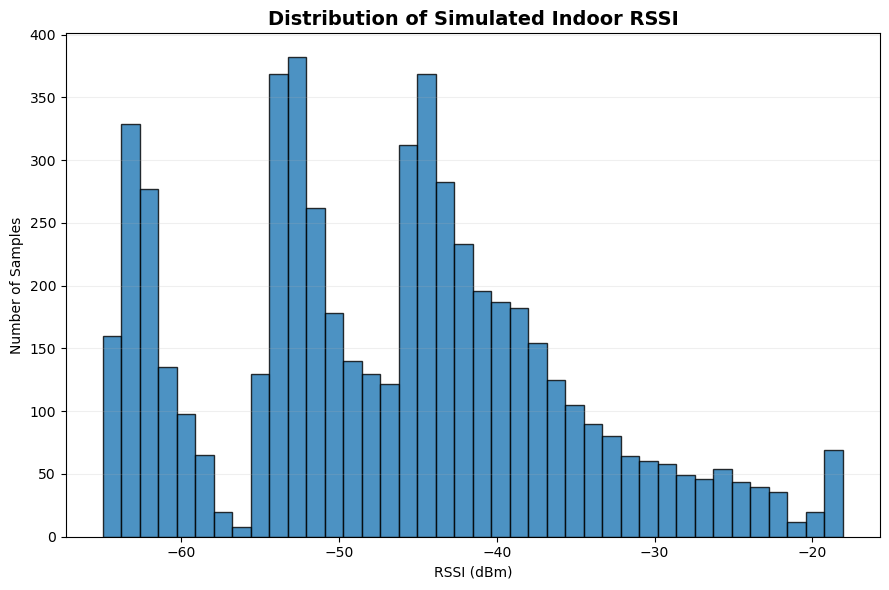

In [33]:
# RSSI DISTRIBUTION

plt.figure(figsize=(9, 6))

plt.hist(
    rf_dataset["rssi_dbm"],
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("RSSI (dBm)")
plt.ylabel("Number of Samples")

plt.title(
    "Distribution of Simulated Indoor RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

rssi_distribution_path = (
    PROJECT_DIR /
    "figures" /
    "rssi_distribution.png"
)

plt.savefig(
    rssi_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


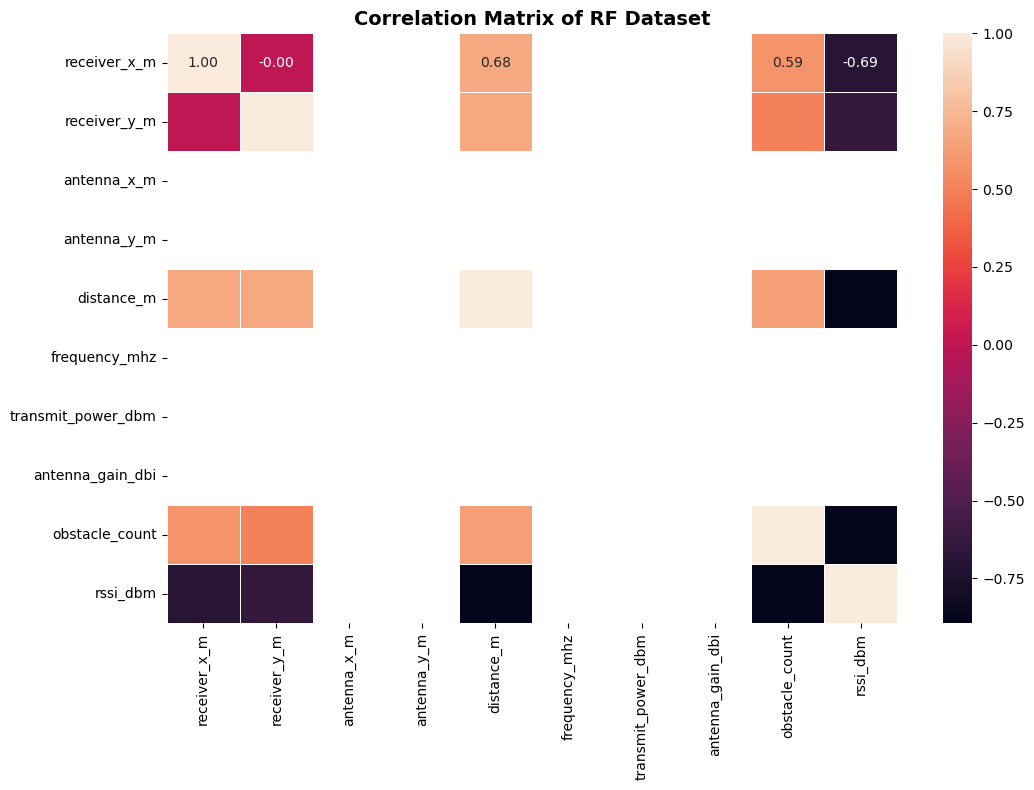

In [34]:

# FEATURE CORRELATION

correlation_matrix = rf_dataset.corr(
    numeric_only=True
)

plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of RF Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

correlation_path = (
    PROJECT_DIR /
    "figures" /
    "rf_dataset_correlation.png"
)

plt.savefig(
    correlation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# SAVE RAW DATASET

raw_dataset_path = (
    PROJECT_DIR /
    "data" /
    "raw" /
    "indoor_rf_dataset.csv"
)

rf_dataset.to_csv(
    raw_dataset_path,
    index=False
)

print("Dataset saved successfully:")
print(raw_dataset_path)

print("\nNumber of samples:", len(rf_dataset))
print("Number of features:", len(rf_dataset.columns) - 1)

Dataset saved successfully:
ML_RFOpt\data\raw\indoor_rf_dataset.csv

Number of samples: 5673
Number of features: 9


In [36]:
# CREATE PROCESSED DATASET

processed_dataset = rf_dataset.copy()

processed_dataset_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "rf_dataset_processed.csv"
)

processed_dataset.to_csv(
    processed_dataset_path,
    index=False
)

print("Processed dataset saved:")
print(processed_dataset_path)

Processed dataset saved:
ML_RFOpt\data\processed\rf_dataset_processed.csv


In [37]:

# VERIFICATION

print("ML-RFOpt — MESSAGE 3 + MESSAGE 4 COMPLETE")

print("\nRF Simulation")

print("Reference path loss:",
      round(reference_path_loss_db, 3), "dB")

print("Path-loss exponent:",
      PATH_LOSS_EXPONENT)

print("Wall attenuation:",
      WALL_LOSS_DB, "dB")

print("\nDataset")

print("Samples:", len(rf_dataset))
print("Columns:", len(rf_dataset.columns))

print(
    "RSSI range:",
    round(rf_dataset["rssi_dbm"].min(), 2),
    "to",
    round(rf_dataset["rssi_dbm"].max(), 2),
    "dBm"
)

print("\nSaved files:")
print(" indoor_rf_dataset.csv")
print(" rf_dataset_processed.csv")
print(" rf_signal_strength_map.png")
print(" rssi_distribution.png")
print(" rf_dataset_correlation.png")

ML-RFOpt — MESSAGE 3 + MESSAGE 4 COMPLETE

RF Simulation
Reference path loss: 40.052 dB
Path-loss exponent: 2.2
Wall attenuation: 8.0 dB

Dataset
Samples: 5673
Columns: 10
RSSI range: -64.98 to -18.05 dBm

Saved files:
 indoor_rf_dataset.csv
 rf_dataset_processed.csv
 rf_signal_strength_map.png
 rssi_distribution.png
 rf_dataset_correlation.png


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset
processed_dataset_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "rf_dataset_processed.csv"
)

rf_dataset = pd.read_csv(processed_dataset_path)

print("Shape:", rf_dataset.shape)

display(rf_dataset.head())


Shape: (5673, 10)


,receiver_x_m,receiver_y_m,antenna_x_m,antenna_y_m,distance_m,frequency_mhz,transmit_power_dbm,antenna_gain_dbi,obstacle_count,rssi_dbm
0,0.00,0.0,2.0,2.0,2.828427,2400,20,2.0,0,-27.985998
1,0.25,0.0,2.0,2.0,2.657536,2400,20,2.0,0,-27.390551
2,0.50,0.0,2.0,2.0,2.500000,2400,20,2.0,0,-26.806688
3,0.75,0.0,2.0,2.0,2.358495,2400,20,2.0,0,-26.249978
4,1.00,0.0,2.0,2.0,2.236068,2400,20,2.0,0,-25.740678


In [39]:
# BASIC DATASET INFORMATION

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nNumber of samples:", len(rf_dataset))
print("Number of columns:", len(rf_dataset.columns))

print("\nColumns:")
for column in rf_dataset.columns:
    print(" -", column)

print("\nData types:")
print(rf_dataset.dtypes)

DATASET INFORMATION

Number of samples: 5673
Number of columns: 10

Columns:
 - receiver_x_m
 - receiver_y_m
 - antenna_x_m
 - antenna_y_m
 - distance_m
 - frequency_mhz
 - transmit_power_dbm
 - antenna_gain_dbi
 - obstacle_count
 - rssi_dbm

Data types:
receiver_x_m          float64
receiver_y_m          float64
antenna_x_m           float64
antenna_y_m           float64
distance_m            float64
frequency_mhz           int64
transmit_power_dbm      int64
antenna_gain_dbi      float64
obstacle_count          int64
rssi_dbm              float64
dtype: object


In [40]:
# MISSING VALUE ANALYSIS

missing_values = rf_dataset.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Count": missing_values.values,
    "Missing_Percentage": (
        missing_values.values /
        len(rf_dataset) *
        100
    )
})

display(missing_table)

,Column,Missing_Count,Missing_Percentage
0,receiver_x_m,0,0.0
1,receiver_y_m,0,0.0
2,antenna_x_m,0,0.0
3,antenna_y_m,0,0.0
4,distance_m,0,0.0
5,frequency_mhz,0,0.0
6,transmit_power_dbm,0,0.0
7,antenna_gain_dbi,0,0.0
8,obstacle_count,0,0.0
9,rssi_dbm,0,0.0


In [41]:
# DUPLICATE ANALYSIS

duplicate_count = rf_dataset.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print(" No duplicate samples detected.")
else:
    print(" Duplicate samples detected.")

Number of duplicate rows: 0
 No duplicate samples detected.


In [42]:
# STATISTICAL SUMMARY

statistics = rf_dataset.describe().T

statistics["median"] = rf_dataset.median(
    numeric_only=True
)

display(statistics)

,count,mean,std,min,25%,50%,75%,max,median
receiver_x_m,5673.0,9.943152,6.070029,0.000000,4.250000,10.000000,15.500000,20.000000,10.000000
receiver_y_m,5673.0,9.964569,6.054450,0.000000,4.500000,9.750000,15.750000,20.000000,9.750000
antenna_x_m,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
antenna_y_m,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
distance_m,5673.0,12.925918,5.739996,1.000000,8.551316,13.729530,17.338541,25.455844,13.729530
frequency_mhz,5673.0,2400.000000,0.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
transmit_power_dbm,5673.0,20.000000,0.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
antenna_gain_dbi,5673.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
obstacle_count,5673.0,0.719901,0.764369,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000
rssi_dbm,5673.0,-46.759638,10.873056,-64.979333,-53.738440,-45.854223,-40.007010,-18.052008,-45.854223


In [43]:
# RSSI STATISTICS

rssi = rf_dataset["rssi_dbm"]

print("RSSI STATISTICS")

print("Minimum RSSI :", round(rssi.min(), 2), "dBm")
print("Maximum RSSI :", round(rssi.max(), 2), "dBm")
print("Mean RSSI    :", round(rssi.mean(), 2), "dBm")
print("Median RSSI  :", round(rssi.median(), 2), "dBm")
print("Std. deviation:", round(rssi.std(), 2), "dB")

RSSI STATISTICS
Minimum RSSI : -64.98 dBm
Maximum RSSI : -18.05 dBm
Mean RSSI    : -46.76 dBm
Median RSSI  : -45.85 dBm
Std. deviation: 10.87 dB


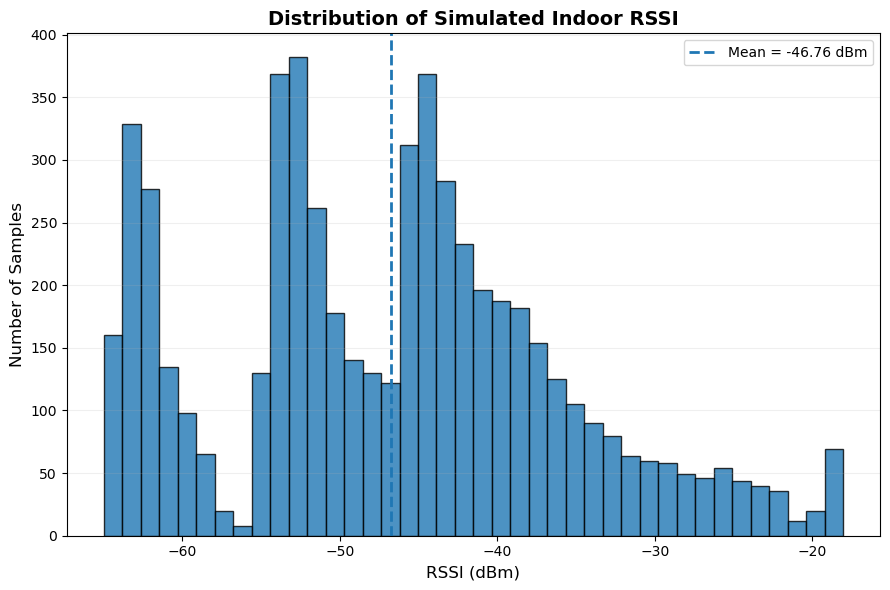

Saved: ML_RFOpt\figures\rssi_histogram.png


In [44]:
# RSSI HISTOGRAM

plt.figure(figsize=(9, 6))

plt.hist(
    rssi,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    rssi.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {rssi.mean():.2f} dBm"
)

plt.xlabel("RSSI (dBm)", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

plt.title(
    "Distribution of Simulated Indoor RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

path = PROJECT_DIR / "figures" / "rssi_histogram.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

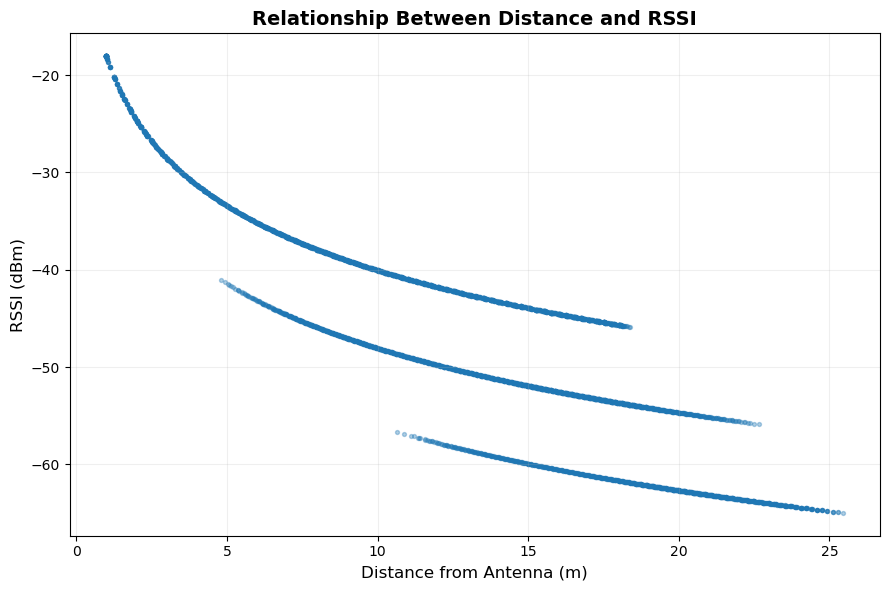

Saved: ML_RFOpt\figures\rssi_vs_distance.png


In [45]:
# RSSI VS DISTANCE

plt.figure(figsize=(9, 6))

plt.scatter(
    rf_dataset["distance_m"],
    rf_dataset["rssi_dbm"],
    s=8,
    alpha=0.35
)

plt.xlabel("Distance from Antenna (m)", fontsize=12)
plt.ylabel("RSSI (dBm)", fontsize=12)

plt.title(
    "Relationship Between Distance and RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.tight_layout()

path = PROJECT_DIR / "figures" / "rssi_vs_distance.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

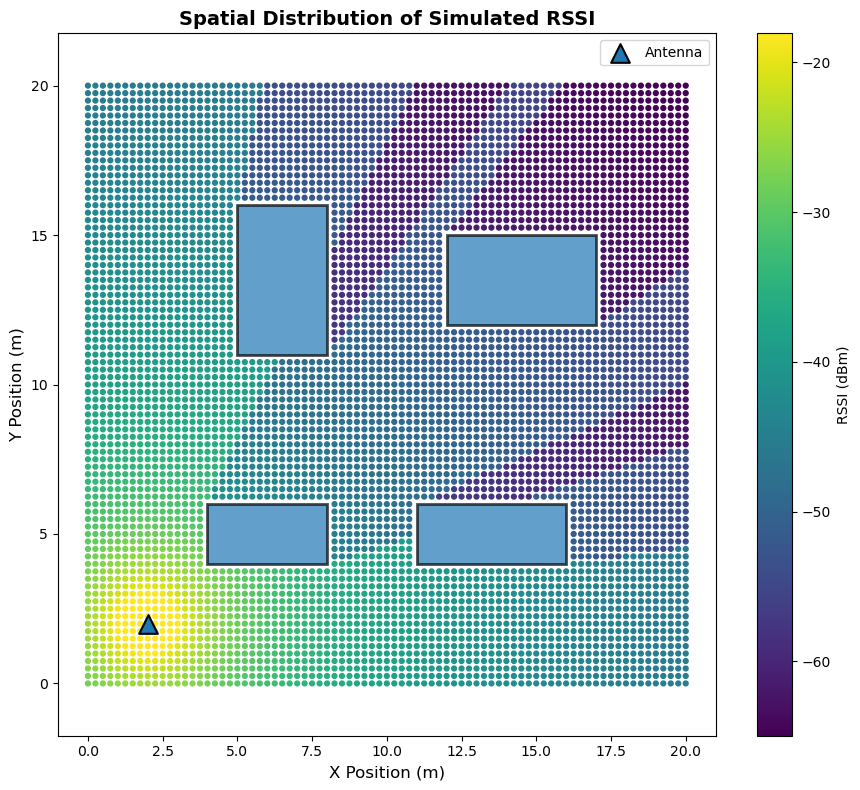

Saved: ML_RFOpt\figures\spatial_rssi_distribution.png


In [46]:
# SPATIAL RSSI DISTRIBUTION

plt.figure(figsize=(9, 8))

scatter = plt.scatter(
    rf_dataset["receiver_x_m"],
    rf_dataset["receiver_y_m"],
    c=rf_dataset["rssi_dbm"],
    s=12,
    cmap="viridis"
)

plt.scatter(
    ANTENNA_X,
    ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5,
    label="Antenna"
)

# Draw obstacles
for i, (
    x_min,
    y_min,
    x_max,
    y_max
) in enumerate(OBSTACLES):

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.xlabel("X Position (m)", fontsize=12)
plt.ylabel("Y Position (m)", fontsize=12)

plt.title(
    "Spatial Distribution of Simulated RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.colorbar(
    scatter,
    label="RSSI (dBm)"
)

plt.legend()
plt.axis("equal")

plt.tight_layout()

path = PROJECT_DIR / "figures" / "spatial_rssi_distribution.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [47]:
# OBSTACLE EFFECT ON RSSI

obstacle_summary = (
    rf_dataset
    .groupby("obstacle_count")["rssi_dbm"]
    .agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    .reset_index()
)

display(obstacle_summary)

,obstacle_count,count,mean,median,std,min,max
0,0,2674,-37.559652,-39.475127,7.094206,-45.870975,-18.052008
1,1,1914,-50.919299,-51.845049,3.083974,-55.863881,-41.056907
2,2,1085,-62.095280,-62.462515,1.725061,-64.979333,-56.641153


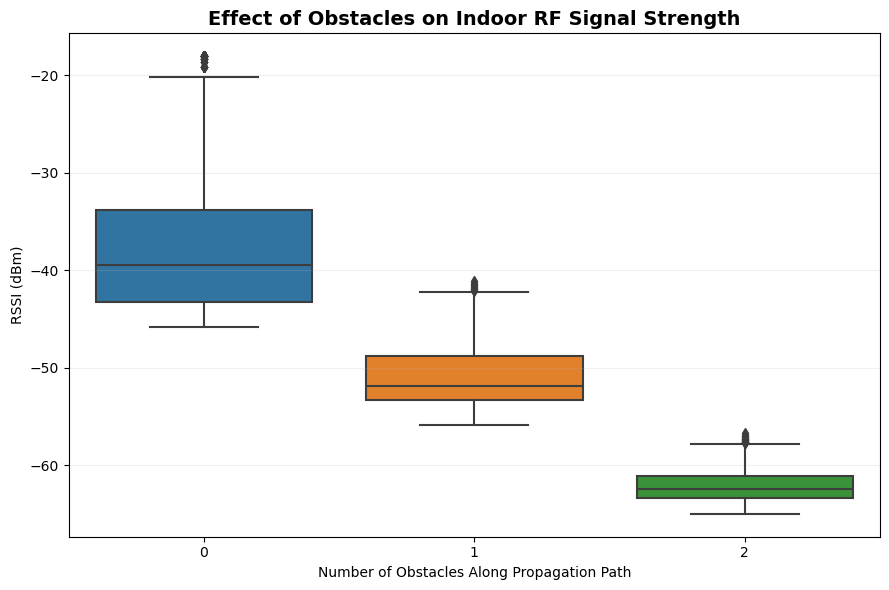

Saved: ML_RFOpt\figures\obstacle_effect_rssi.png


In [48]:
# OBSTACLE COUNT VS RSSI

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=rf_dataset,
    x="obstacle_count",
    y="rssi_dbm"
)

plt.xlabel("Number of Obstacles Along Propagation Path")
plt.ylabel("RSSI (dBm)")

plt.title(
    "Effect of Obstacles on Indoor RF Signal Strength",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

path = PROJECT_DIR / "figures" / "obstacle_effect_rssi.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [49]:
# RF COVERAGE CLASSIFICATION

def classify_rssi(rssi_value):

    if rssi_value >= -60:
        return "Excellent"

    elif rssi_value >= -70:
        return "Good"

    elif rssi_value >= -80:
        return "Fair"

    else:
        return "Weak"


rf_dataset["coverage_class"] = (
    rf_dataset["rssi_dbm"]
    .apply(classify_rssi)
)

coverage_counts = (
    rf_dataset["coverage_class"]
    .value_counts()
)

coverage_percentages = (
    coverage_counts /
    len(rf_dataset) *
    100
)

coverage_table = pd.DataFrame({
    "Samples": coverage_counts,
    "Percentage": coverage_percentages.round(2)
})

display(coverage_table)

,Samples,Percentage
coverage_class,,
Excellent,4746,83.66
Good,927,16.34


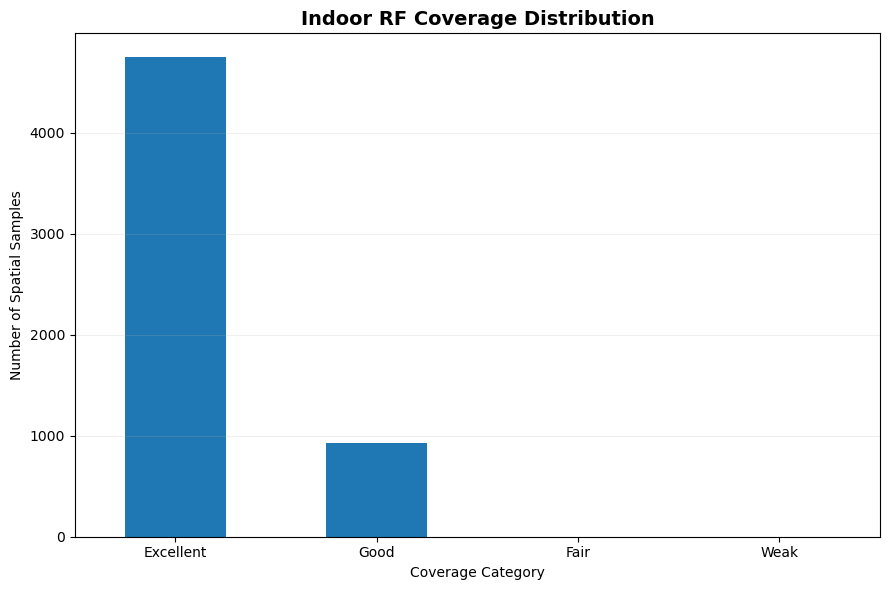

Saved: ML_RFOpt\figures\rf_coverage_distribution.png


In [50]:
# COVERAGE DISTRIBUTION

coverage_order = [
    "Excellent",
    "Good",
    "Fair",
    "Weak"
]

coverage_plot_data = (
    rf_dataset["coverage_class"]
    .value_counts()
    .reindex(coverage_order)
    .fillna(0)
)

plt.figure(figsize=(9, 6))

coverage_plot_data.plot(
    kind="bar"
)

plt.xlabel("Coverage Category")
plt.ylabel("Number of Spatial Samples")

plt.title(
    "Indoor RF Coverage Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

path = PROJECT_DIR / "figures" / "rf_coverage_distribution.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [52]:
# DATA QUALITY CHECK

print("DATA QUALITY REPORT")

print(
    "\nMissing values:",
    rf_dataset.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    rf_dataset.duplicated().sum()
)

print(
    "Infinite values:",
    np.isinf(
        rf_dataset.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Minimum RSSI:",
    rf_dataset["rssi_dbm"].min()
)

print(
    "Maximum RSSI:",
    rf_dataset["rssi_dbm"].max()
)

DATA QUALITY REPORT

Missing values: 0
Duplicate rows: 0
Infinite values: 0
Minimum RSSI: -64.97933312069202
Maximum RSSI: -18.052008056115497


In [53]:
# FEATURE / TARGET SELECTION

FEATURE_COLUMNS = [
    "receiver_x_m",
    "receiver_y_m",
    "antenna_x_m",
    "antenna_y_m",
    "distance_m",
    "frequency_mhz",
    "transmit_power_dbm",
    "antenna_gain_dbi",
    "obstacle_count"
]

TARGET_COLUMN = "rssi_dbm"

X_data = rf_dataset[FEATURE_COLUMNS].copy()

y_data = rf_dataset[TARGET_COLUMN].copy()

print("Features:")
for feature in FEATURE_COLUMNS:
    print(" ", feature)

print("\nTarget:")
print(" ", TARGET_COLUMN)

print("\nFeature matrix shape:", X_data.shape)
print("Target shape:", y_data.shape)

Features:
  receiver_x_m
  receiver_y_m
  antenna_x_m
  antenna_y_m
  distance_m
  frequency_mhz
  transmit_power_dbm
  antenna_gain_dbi
  obstacle_count

Target:
  rssi_dbm

Feature matrix shape: (5673, 9)
Target shape: (5673,)


In [54]:
# FEATURE MATRIX CHECK

print("FEATURE MATRIX")

display(X_data.head())

print("\nTarget values:")
display(y_data.head())

FEATURE MATRIX


,receiver_x_m,receiver_y_m,antenna_x_m,antenna_y_m,distance_m,frequency_mhz,transmit_power_dbm,antenna_gain_dbi,obstacle_count
0,0.00,0.0,2.0,2.0,2.828427,2400,20,2.0,0
1,0.25,0.0,2.0,2.0,2.657536,2400,20,2.0,0
2,0.50,0.0,2.0,2.0,2.500000,2400,20,2.0,0
3,0.75,0.0,2.0,2.0,2.358495,2400,20,2.0,0
4,1.00,0.0,2.0,2.0,2.236068,2400,20,2.0,0



Target values:


0   -27.985998
1   -27.390551
2   -26.806688
3   -26.249978
4   -25.740678
Name: rssi_dbm, dtype: float64

In [55]:
# TRAIN / VALIDATION / TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_data,
    y_data,
    test_size=0.30,
    random_state=SEED
)


X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED
)

print("Training samples   :", len(X_train))
print("Validation samples :", len(X_validation))
print("Testing samples    :", len(X_test))

print("\nTotal samples      :", len(X_data))

Training samples   : 3971
Validation samples : 851
Testing samples    : 851

Total samples      : 5673


In [56]:
# VERIFY DATA SPLIT

total_samples = len(X_data)

train_percentage = (
    len(X_train) /
    total_samples *
    100
)

validation_percentage = (
    len(X_validation) /
    total_samples *
    100
)

test_percentage = (
    len(X_test) /
    total_samples *
    100
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "Samples": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Percentage": [
        train_percentage,
        validation_percentage,
        test_percentage
    ]
})

display(split_summary)

,Dataset,Samples,Percentage
0,Training,3971,69.998237
1,Validation,851,15.000881
2,Testing,851,15.000881


In [57]:
# FEATURE STANDARDIZATION

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")
print(
    "Training matrix:",
    X_train_scaled.shape
)

print(
    "Validation matrix:",
    X_validation_scaled.shape
)

print(
    "Testing matrix:",
    X_test_scaled.shape
)

Feature scaling completed.
Training matrix: (3971, 9)
Validation matrix: (851, 9)
Testing matrix: (851, 9)


In [58]:
# VERIFY STANDARDIZATION

scaled_means = X_train_scaled.mean(axis=0)
scaled_std = X_train_scaled.std(axis=0)

scaling_check = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Mean": scaled_means,
    "Std": scaled_std
})

display(scaling_check)

,Feature,Mean,Std
0,receiver_x_m,-1.386730e-16,1.0
1,receiver_y_m,1.163064e-16,1.0
2,antenna_x_m,0.000000e+00,0.0
3,antenna_y_m,0.000000e+00,0.0
4,distance_m,1.055704e-16,1.0
5,frequency_mhz,0.000000e+00,0.0
6,transmit_power_dbm,0.000000e+00,0.0
7,antenna_gain_dbi,0.000000e+00,0.0
8,obstacle_count,-4.831190e-17,1.0


In [59]:
# SAVE PREPROCESSING OBJECTS

import joblib

scaler_path = (
    PROJECT_DIR /
    "models" /
    "feature_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler saved:")
print(scaler_path)

Scaler saved:
ML_RFOpt\models\feature_scaler.pkl


In [60]:
# SAVE DATA SPLITS

train_data = X_train.copy()
train_data[TARGET_COLUMN] = y_train.values

validation_data = X_validation.copy()
validation_data[TARGET_COLUMN] = y_validation.values

test_data = X_test.copy()
test_data[TARGET_COLUMN] = y_test.values

train_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "train.csv"
)

validation_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "validation.csv"
)

test_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "test.csv"
)

train_data.to_csv(
    train_path,
    index=False
)

validation_data.to_csv(
    validation_path,
    index=False
)

test_data.to_csv(
    test_path,
    index=False
)

print("Saved:")
print(" ", train_path)
print(" ", validation_path)
print(" ", test_path)

Saved:
  ML_RFOpt\data\processed\train.csv
  ML_RFOpt\data\processed\validation.csv
  ML_RFOpt\data\processed\test.csv


In [61]:
# MULTI-CONFIGURATION RF DATASET

N_CONFIGURATIONS = 30

TRANSMIT_POWER_OPTIONS = [
    15.0,
    20.0,
    25.0
]

FREQUENCY_OPTIONS_MHZ = [
    1800.0,
    2400.0,
    3500.0
]


print("Number of configurations:", N_CONFIGURATIONS)
print("Transmit powers:", TRANSMIT_POWER_OPTIONS)
print("Frequencies:", FREQUENCY_OPTIONS_MHZ)

Number of configurations: 30
Transmit powers: [15.0, 20.0, 25.0]
Frequencies: [1800.0, 2400.0, 3500.0]


In [62]:
# CHECK WHETHER A POINT IS INSIDE AN OBSTACLE

def point_inside_obstacle(x, y, obstacles=OBSTACLES):

    for x_min, y_min, x_max, y_max in obstacles:

        if (
            x_min <= x <= x_max
            and
            y_min <= y <= y_max
        ):
            return True

    return False

In [63]:
# GENERATE VALID ANTENNA POSITIONS

def generate_antenna_positions(
    number_of_positions,
    room_width=ROOM_WIDTH,
    room_height=ROOM_HEIGHT,
    margin=1.0,
    seed=SEED
):

    rng = np.random.default_rng(seed)

    positions = []

    while len(positions) < number_of_positions:

        x = rng.uniform(
            margin,
            room_width - margin
        )

        y = rng.uniform(
            margin,
            room_height - margin
        )

        # Avoid obstacles
        if not point_inside_obstacle(x, y):

            positions.append(
                (round(x, 2), round(y, 2))
            )

    return positions

In [65]:
# CREATE MULTIPLE RF CONFIGURATIONS

antenna_positions = generate_antenna_positions(
    N_CONFIGURATIONS,
    seed=SEED
)

rng = np.random.default_rng(SEED)

configuration_records = []

for config_id in range(N_CONFIGURATIONS):

    antenna_x, antenna_y = antenna_positions[config_id]

    transmit_power = rng.choice(
        TRANSMIT_POWER_OPTIONS
    )

    frequency = rng.choice(
        FREQUENCY_OPTIONS_MHZ
    )

    configuration_records.append({
        "config_id": config_id,
        "antenna_x_m": antenna_x,
        "antenna_y_m": antenna_y,
        "frequency_mhz": frequency,
        "transmit_power_dbm": transmit_power,
        "antenna_gain_dbi": ANTENNA_GAIN_DBI
    })

configuration_table = pd.DataFrame(
    configuration_records
)

display(configuration_table)

,config_id,antenna_x_m,antenna_y_m,frequency_mhz,transmit_power_dbm,antenna_gain_dbi
0,0,14.93,8.90,3500.0,15.0,2.0
1,1,2.70,18.56,2400.0,20.0,2.0
2,2,14.70,15.15,3500.0,20.0,2.0
3,3,3.31,9.11,3500.0,15.0,2.0
4,4,7.67,17.68,1800.0,15.0,2.0
5,5,12.59,15.81,3500.0,20.0,2.0
6,6,8.98,5.09,3500.0,25.0,2.0
7,7,10.98,2.15,3500.0,25.0,2.0
8,8,14.65,7.38,1800.0,20.0,2.0
9,9,18.47,17.08,2400.0,25.0,2.0


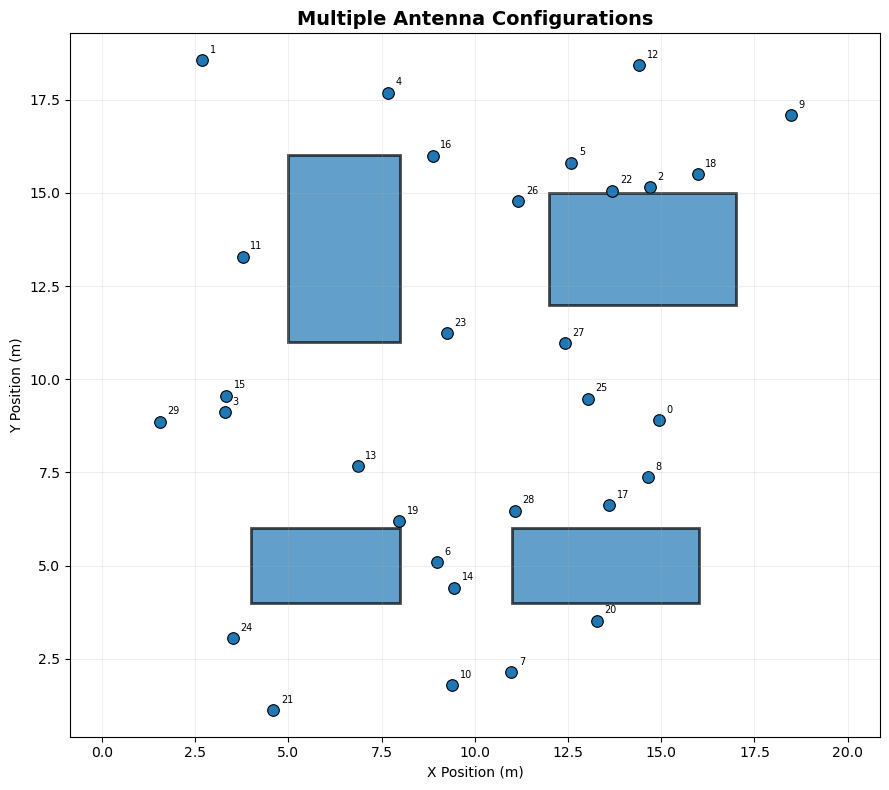

Saved: ML_RFOpt\figures\multiple_antenna_configurations.png


In [66]:
# VISUALIZE MULTIPLE ANTENNA CONFIGURATIONS

plt.figure(figsize=(9, 8))

# Obstacles
for i, (
    x_min,
    y_min,
    x_max,
    y_max
) in enumerate(OBSTACLES):

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

# Antenna positions
plt.scatter(
    configuration_table["antenna_x_m"],
    configuration_table["antenna_y_m"],
    s=70,
    edgecolor="black",
    linewidth=0.8
)

# Configuration labels
for _, row in configuration_table.iterrows():

    plt.text(
        row["antenna_x_m"] + 0.2,
        row["antenna_y_m"] + 0.2,
        str(int(row["config_id"])),
        fontsize=7
    )

plt.xlim(0, ROOM_WIDTH)
plt.ylim(0, ROOM_HEIGHT)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "Multiple Antenna Configurations",
    fontsize=14,
    fontweight="bold"
)

plt.axis("equal")
plt.grid(alpha=0.2)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "multiple_antenna_configurations.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [67]:
# FREQUENCY-AWARE RSSI FUNCTION

def calculate_rssi_with_frequency(
    antenna_position,
    receiver_position,
    frequency_mhz,
    transmit_power_dbm,
    transmitter_gain_dbi=ANTENNA_GAIN_DBI,
    receiver_gain_dbi=RECEIVER_GAIN_DBI,
    wall_loss_db=WALL_LOSS_DB
):

    antenna_x, antenna_y = antenna_position
    receiver_x, receiver_y = receiver_position


    distance = np.sqrt(
        (receiver_x - antenna_x) ** 2
        +
        (receiver_y - antenna_y) ** 2
    )

    distance = max(
        distance,
        REFERENCE_DISTANCE
    )

    frequency_hz = frequency_mhz * 1e6

    wavelength = SPEED_OF_LIGHT / frequency_hz

    reference_loss_db = (
        20 *
        np.log10(
            (4 * np.pi * REFERENCE_DISTANCE)
            / wavelength
        )
    )

    path_loss = (
        reference_loss_db
        +
        10 *
        PATH_LOSS_EXPONENT *
        np.log10(
            distance /
            REFERENCE_DISTANCE
        )
    )

    obstacle_count = count_obstacle_crossings(
        antenna_position,
        receiver_position
    )

    obstacle_loss = (
        obstacle_count *
        wall_loss_db
    )

    rssi = (
        transmit_power_dbm
        +
        transmitter_gain_dbi
        +
        receiver_gain_dbi
        -
        path_loss
        -
        obstacle_loss
    )

    rssi = max(
        rssi,
        MIN_RSSI_DBM
    )

    return (
        rssi,
        distance,
        obstacle_count
    )

In [68]:
# GENERATE MULTI-CONFIGURATION RF DATASET

multi_config_records = []

print("Generating RF dataset...")
print("Configurations:", N_CONFIGURATIONS)

for _, config in configuration_table.iterrows():

    config_id = int(config["config_id"])

    antenna_x = config["antenna_x_m"]
    antenna_y = config["antenna_y_m"]

    frequency = config["frequency_mhz"]

    transmit_power = config["transmit_power_dbm"]

    antenna_position = (
        antenna_x,
        antenna_y
    )

    for row in range(X.shape[0]):

        for col in range(X.shape[1]):

            receiver_x = X[row, col]
            receiver_y = Y[row, col]

            if obstacle_mask[row, col]:
                continue

            (
                rssi,
                distance,
                obstacle_count
            ) = calculate_rssi_with_frequency(
                antenna_position,
                (receiver_x, receiver_y),
                frequency,
                transmit_power
            )

            multi_config_records.append({
                "config_id": config_id,
                "receiver_x_m": receiver_x,
                "receiver_y_m": receiver_y,
                "antenna_x_m": antenna_x,
                "antenna_y_m": antenna_y,
                "distance_m": distance,
                "frequency_mhz": frequency,
                "transmit_power_dbm": transmit_power,
                "antenna_gain_dbi": ANTENNA_GAIN_DBI,
                "obstacle_count": obstacle_count,
                "rssi_dbm": rssi
            })

    print(
        f"Configuration {config_id + 1}/{N_CONFIGURATIONS} completed."
    )

multi_config_dataset = pd.DataFrame(
    multi_config_records
)

print("\nDataset generation completed.")
print(
    "Dataset shape:",
    multi_config_dataset.shape
)

Generating RF dataset...
Configurations: 30
Configuration 1/30 completed.
Configuration 2/30 completed.
Configuration 3/30 completed.
Configuration 4/30 completed.
Configuration 5/30 completed.
Configuration 6/30 completed.
Configuration 7/30 completed.
Configuration 8/30 completed.
Configuration 9/30 completed.
Configuration 10/30 completed.
Configuration 11/30 completed.
Configuration 12/30 completed.
Configuration 13/30 completed.
Configuration 14/30 completed.
Configuration 15/30 completed.
Configuration 16/30 completed.
Configuration 17/30 completed.
Configuration 18/30 completed.
Configuration 19/30 completed.
Configuration 20/30 completed.
Configuration 21/30 completed.
Configuration 22/30 completed.
Configuration 23/30 completed.
Configuration 24/30 completed.
Configuration 25/30 completed.
Configuration 26/30 completed.
Configuration 27/30 completed.
Configuration 28/30 completed.
Configuration 29/30 completed.
Configuration 30/30 completed.

Dataset generation completed.
Data

In [69]:
# CHECK MULTI-CONFIGURATION DATASET

print("MULTI-CONFIGURATION DATASET")

print(
    "Total samples:",
    len(multi_config_dataset)
)

print(
    "Number of configurations:",
    multi_config_dataset["config_id"].nunique()
)

print(
    "Number of frequencies:",
    multi_config_dataset["frequency_mhz"].nunique()
)

print(
    "Number of transmit powers:",
    multi_config_dataset["transmit_power_dbm"].nunique()
)

display(
    multi_config_dataset.head()
)

MULTI-CONFIGURATION DATASET
Total samples: 170190
Number of configurations: 30
Number of frequencies: 3
Number of transmit powers: 3


,config_id,receiver_x_m,receiver_y_m,antenna_x_m,antenna_y_m,distance_m,frequency_mhz,transmit_power_dbm,antenna_gain_dbi,obstacle_count,rssi_dbm
0,0,0.00,0.0,14.93,8.9,17.381453,3500.0,15.0,2.0,1,-61.611038
1,0,0.25,0.0,14.93,8.9,17.167190,3500.0,15.0,2.0,1,-61.492527
2,0,0.50,0.0,14.93,8.9,16.953905,3500.0,15.0,2.0,1,-61.373079
3,0,0.75,0.0,14.93,8.9,16.741637,3500.0,15.0,2.0,1,-61.252698
4,0,1.00,0.0,14.93,8.9,16.530423,3500.0,15.0,2.0,1,-61.131392


In [70]:
# SAVE MULTI-CONFIGURATION DATASET

multi_config_path = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "multi_configuration_rf_dataset.csv"
)

multi_config_dataset.to_csv(
    multi_config_path,
    index=False
)

print("Saved:")
print(multi_config_path)

Saved:
ML_RFOpt\data\processed\multi_configuration_rf_dataset.csv


In [71]:
# CONFIGURATION-LEVEL SPLITTING

from sklearn.model_selection import train_test_split

unique_configurations = (
    multi_config_dataset["config_id"]
    .unique()
)

train_configs, temp_configs = train_test_split(
    unique_configurations,
    test_size=0.30,
    random_state=SEED
)

validation_configs, test_configs = train_test_split(
    temp_configs,
    test_size=0.50,
    random_state=SEED
)

print("Training configurations:")
print(train_configs)

print("\nValidation configurations:")
print(validation_configs)

print("\nTesting configurations:")
print(test_configs)

Training configurations:
[ 0  4 16  5 13 11 22  1  2 25  3 21 26 18 29 20  7 10 14 19  6]

Validation configurations:
[23  8 17 28]

Testing configurations:
[24 15  9 27 12]


In [72]:
# CREATE CONFIGURATION-BASED DATA SPLITS

train_df = multi_config_dataset[
    multi_config_dataset["config_id"].isin(
        train_configs
    )
].copy()

validation_df = multi_config_dataset[
    multi_config_dataset["config_id"].isin(
        validation_configs
    )
].copy()

test_df = multi_config_dataset[
    multi_config_dataset["config_id"].isin(
        test_configs
    )
].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Testing samples:", len(test_df))

Training samples: 119133
Validation samples: 22692
Testing samples: 28365


In [73]:
# ML FEATURES

FEATURE_COLUMNS = [
    "receiver_x_m",
    "receiver_y_m",
    "antenna_x_m",
    "antenna_y_m",
    "distance_m",
    "frequency_mhz",
    "transmit_power_dbm",
    "antenna_gain_dbi",
    "obstacle_count"
]

TARGET_COLUMN = "rssi_dbm"

X_train = train_df[
    FEATURE_COLUMNS
].copy()

y_train = train_df[
    TARGET_COLUMN
].copy()

X_validation = validation_df[
    FEATURE_COLUMNS
].copy()

y_validation = validation_df[
    TARGET_COLUMN
].copy()

X_test = test_df[
    FEATURE_COLUMNS
].copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (119133, 9)
X_validation: (22692, 9)
X_test: (28365, 9)


In [75]:
# RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=150,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1
)


random_forest.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=25, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=150, n_jobs=-1,
                      random_state=42)

In [77]:
# RANDOM FOREST VALIDATION

rf_validation_prediction = (
    random_forest.predict(
        X_validation
    )
)

print(
    "Validation predictions generated:",
    len(rf_validation_prediction)
)

Validation predictions generated: 22692


In [78]:
# SAVE RANDOM FOREST MODEL

rf_model_path = (
    PROJECT_DIR /
    "models" /
    "random_forest_rssi_model.pkl"
)

joblib.dump(
    random_forest,
    rf_model_path
)

print("Random Forest saved:")
print(rf_model_path)

Random Forest saved:
ML_RFOpt\models\random_forest_rssi_model.pkl


In [79]:
# MLP FEATURE STANDARDIZATION

from sklearn.preprocessing import StandardScaler

mlp_scaler = StandardScaler()

X_train_mlp = mlp_scaler.fit_transform(
    X_train
)

X_validation_mlp = mlp_scaler.transform(
    X_validation
)

X_test_mlp = mlp_scaler.transform(
    X_test
)

print("MLP scaling completed.")

print(
    "Training:",
    X_train_mlp.shape
)

print(
    "Validation:",
    X_validation_mlp.shape
)

print(
    "Testing:",
    X_test_mlp.shape
)

MLP scaling completed.
Training: (119133, 9)
Validation: (22692, 9)
Testing: (28365, 9)


In [80]:
# MLP REGRESSOR

from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=150,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    random_state=SEED
)

print("Training MLP...")

mlp_model.fit(
    X_train_mlp,
    y_train
)

print("✓ MLP training completed.")
print(
    "Training iterations:",
    mlp_model.n_iter_
)

Training MLP...
✓ MLP training completed.
Training iterations: 20


In [81]:
# MLP VALIDATION PREDICTION

mlp_validation_prediction = (
    mlp_model.predict(
        X_validation_mlp
    )
)

print(
    "MLP validation predictions:",
    len(mlp_validation_prediction)
)

MLP validation predictions: 22692


In [82]:
# SAVE MLP MODEL

mlp_model_path = (
    PROJECT_DIR /
    "models" /
    "mlp_rssi_model.pkl"
)

mlp_scaler_path = (
    PROJECT_DIR /
    "models" /
    "mlp_scaler.pkl"
)

joblib.dump(
    mlp_model,
    mlp_model_path
)

joblib.dump(
    mlp_scaler,
    mlp_scaler_path
)

print("MLP saved:")
print(mlp_model_path)

print("MLP scaler saved:")
print(mlp_scaler_path)

MLP saved:
ML_RFOpt\models\mlp_rssi_model.pkl
MLP scaler saved:
ML_RFOpt\models\mlp_scaler.pkl


In [83]:
# FINAL TEST PREDICTIONS

rf_test_prediction = (
    random_forest.predict(
        X_test
    )
)

mlp_test_prediction = (
    mlp_model.predict(
        X_test_mlp
    )
)

In [84]:
# MODEL EVALUATION FUNCTION

def evaluate_regression_model(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    mean_error = np.mean(
        predicted - actual
    )

    return {
        "MAE_dB": mae,
        "RMSE_dB": rmse,
        "R2": r2,
        "Mean_Error_dB": mean_error
    }

In [85]:
# CALCULATE TEST METRICS

rf_metrics = evaluate_regression_model(
    y_test,
    rf_test_prediction
)

mlp_metrics = evaluate_regression_model(
    y_test,
    mlp_test_prediction
)

metrics_table = pd.DataFrame(
    [
        rf_metrics,
        mlp_metrics
    ],
    index=[
        "Random Forest",
        "MLP"
    ]
)

display(
    metrics_table.round(4)
)

,MAE_dB,RMSE_dB,R2,Mean_Error_dB
Random Forest,1.5840,2.0306,0.9600,-1.1114
MLP,1.0341,1.1839,0.9864,-0.8193


In [86]:
# SAVE MODEL METRICS

metrics_path = (
    PROJECT_DIR /
    "results" /
    "model_comparison_metrics.csv"
)

metrics_table.to_csv(
    metrics_path
)

print("Metrics saved:")
print(metrics_path)

Metrics saved:
ML_RFOpt\results\model_comparison_metrics.csv


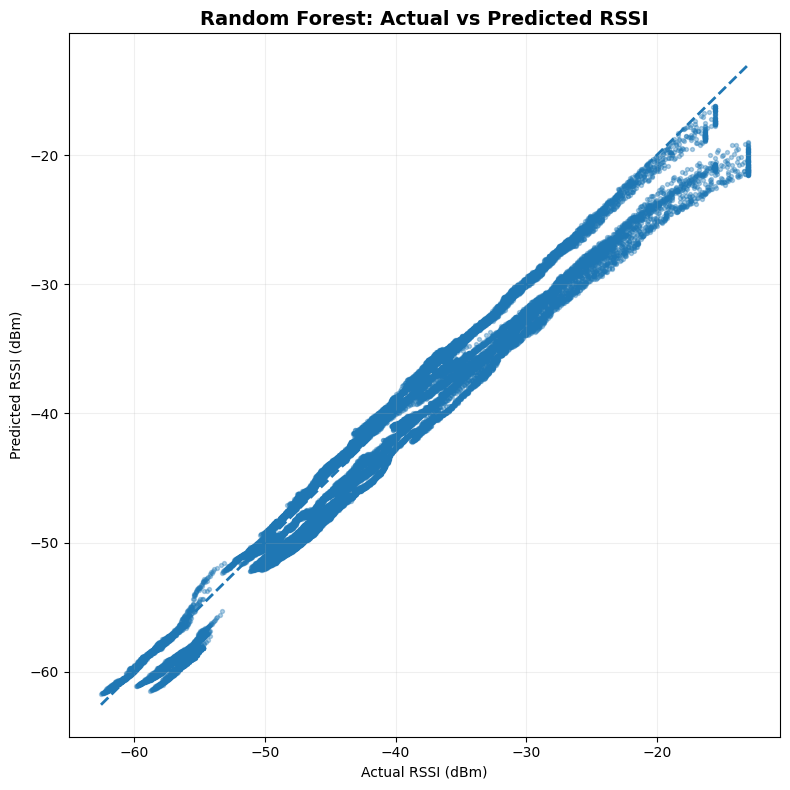

Saved: ML_RFOpt\figures\random_forest_actual_vs_predicted.png


In [87]:
# RANDOM FOREST — ACTUAL VS PREDIC

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    rf_test_prediction,
    s=8,
    alpha=0.35
)

minimum = min(
    y_test.min(),
    rf_test_prediction.min()
)

maximum = max(
    y_test.max(),
    rf_test_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual RSSI (dBm)")
plt.ylabel("Predicted RSSI (dBm)")

plt.title(
    "Random Forest: Actual vs Predicted RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "random_forest_actual_vs_predicted.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

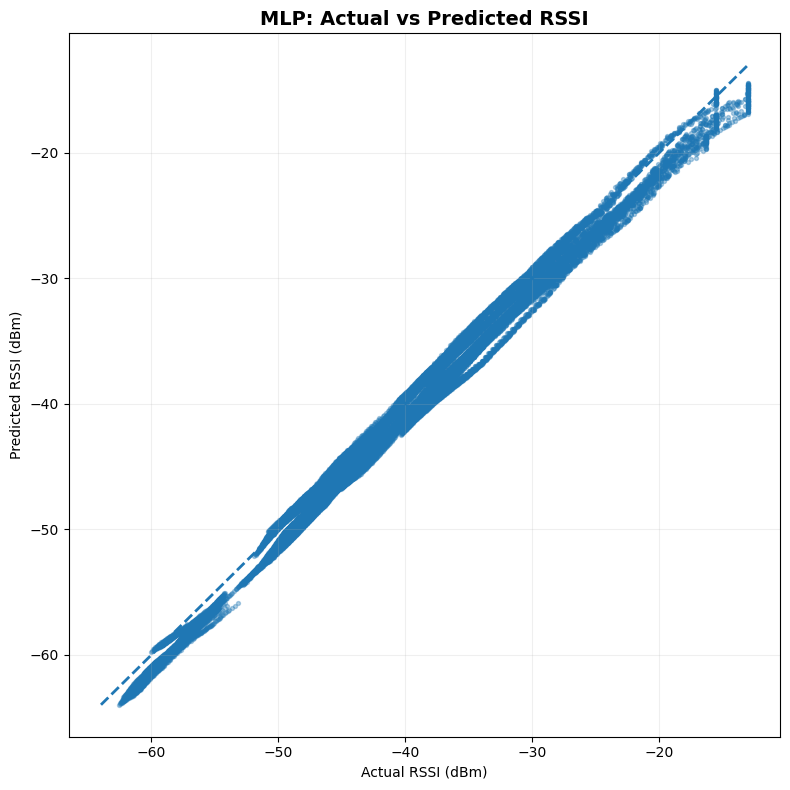

Saved: ML_RFOpt\figures\mlp_actual_vs_predicted.png


In [88]:
# MLP — ACTUAL VS PREDICTED

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    mlp_test_prediction,
    s=8,
    alpha=0.35
)

minimum = min(
    y_test.min(),
    mlp_test_prediction.min()
)

maximum = max(
    y_test.max(),
    mlp_test_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual RSSI (dBm)")
plt.ylabel("Predicted RSSI (dBm)")

plt.title(
    "MLP: Actual vs Predicted RSSI",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "mlp_actual_vs_predicted.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

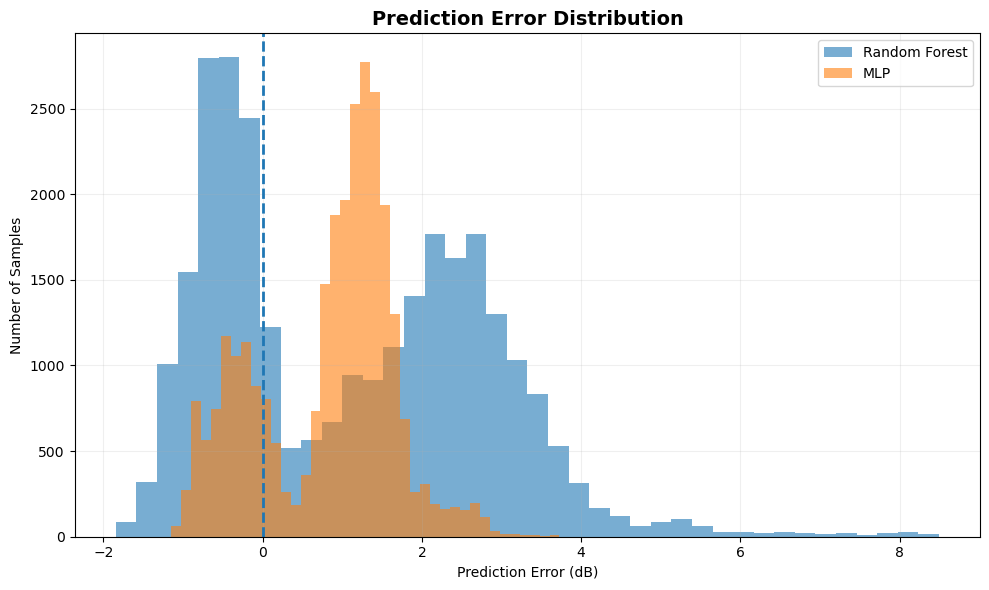

Saved: ML_RFOpt\figures\model_residual_distribution.png


In [89]:
# RESIDUAL ANALYSIS

rf_residuals = (
    y_test.values -
    rf_test_prediction
)

mlp_residuals = (
    y_test.values -
    mlp_test_prediction
)

plt.figure(figsize=(10, 6))

plt.hist(
    rf_residuals,
    bins=40,
    alpha=0.6,
    label="Random Forest"
)

plt.hist(
    mlp_residuals,
    bins=40,
    alpha=0.6,
    label="MLP"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (dB)")
plt.ylabel("Number of Samples")

plt.title(
    "Prediction Error Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "model_residual_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [90]:
# RANDOM FOREST FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(feature_importance)

,Feature,Importance
8,obstacle_count,0.443365
4,distance_m,0.314238
6,transmit_power_dbm,0.096009
2,antenna_x_m,0.041847
3,antenna_y_m,0.030223
5,frequency_mhz,0.027752
1,receiver_y_m,0.025353
0,receiver_x_m,0.021213
7,antenna_gain_dbi,0.000000


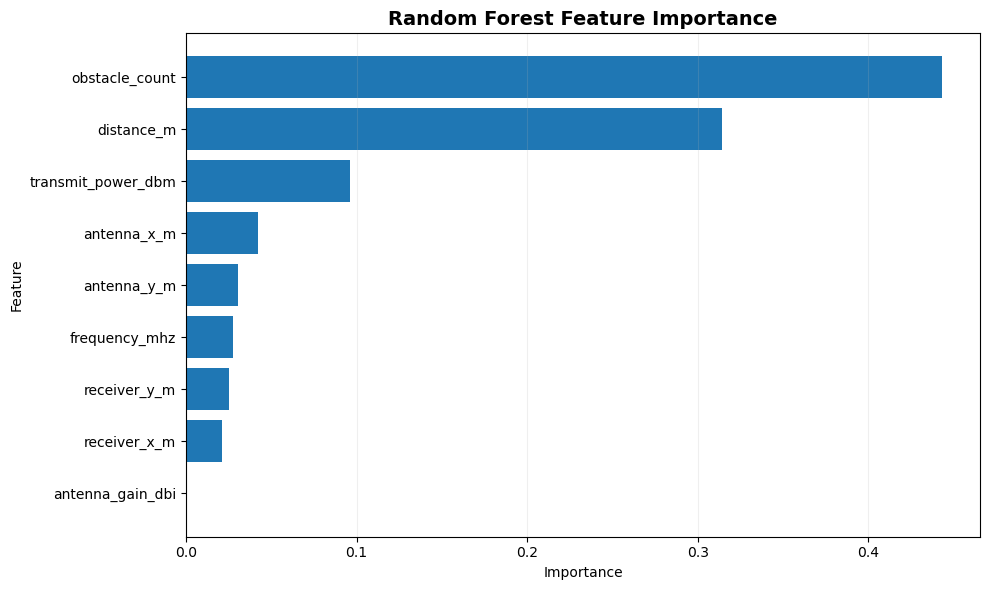

Saved: ML_RFOpt\figures\random_forest_feature_importance.png


In [91]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "random_forest_feature_importance.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [92]:
# SELECT AN UNSEEN TEST CONFIGURATION

selected_test_config = int(
    test_configs[0]
)

selected_config = (
    configuration_table[
        configuration_table["config_id"]
        == selected_test_config
    ]
    .iloc[0]
)

TEST_ANTENNA_X = selected_config[
    "antenna_x_m"
]

TEST_ANTENNA_Y = selected_config[
    "antenna_y_m"
]

TEST_FREQUENCY = selected_config[
    "frequency_mhz"
]

TEST_POWER = selected_config[
    "transmit_power_dbm"
]

print("Selected unseen test configuration:")

print("Configuration ID:", selected_test_config)
print("Antenna X:", TEST_ANTENNA_X)
print("Antenna Y:", TEST_ANTENNA_Y)
print("Frequency:", TEST_FREQUENCY, "MHz")
print("Transmit power:", TEST_POWER, "dBm")

Selected unseen test configuration:
Configuration ID: 24
Antenna X: 3.52
Antenna Y: 3.06
Frequency: 3500.0 MHz
Transmit power: 25.0 dBm


In [93]:
# GENERATE GROUND-TRUTH RF FIELD FOR TEST CONFIGURATION

test_rssi_map = np.full_like(
    X,
    np.nan,
    dtype=float
)

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        if obstacle_mask[row, col]:
            continue

        (
            rssi,
            distance,
            obstacle_count
        ) = calculate_rssi_with_frequency(
            (
                TEST_ANTENNA_X,
                TEST_ANTENNA_Y
            ),
            (
                receiver_x,
                receiver_y
            ),
            TEST_FREQUENCY,
            TEST_POWER
        )

        test_rssi_map[row, col] = rssi

print("Ground-truth test RF field generated.")

Ground-truth test RF field generated.


In [94]:
# CREATE TEST GRID FOR ML PREDICTION

heatmap_records = []

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        if obstacle_mask[row, col]:
            continue

        (
            actual_rssi,
            distance,
            obstacle_count
        ) = calculate_rssi_with_frequency(
            (
                TEST_ANTENNA_X,
                TEST_ANTENNA_Y
            ),
            (
                receiver_x,
                receiver_y
            ),
            TEST_FREQUENCY,
            TEST_POWER
        )

        heatmap_records.append({
            "receiver_x_m": receiver_x,
            "receiver_y_m": receiver_y,
            "antenna_x_m": TEST_ANTENNA_X,
            "antenna_y_m": TEST_ANTENNA_Y,
            "distance_m": distance,
            "frequency_mhz": TEST_FREQUENCY,
            "transmit_power_dbm": TEST_POWER,
            "antenna_gain_dbi": ANTENNA_GAIN_DBI,
            "obstacle_count": obstacle_count,
            "actual_rssi_dbm": actual_rssi
        })

heatmap_df = pd.DataFrame(
    heatmap_records
)

print("Heatmap prediction dataset:")
print(heatmap_df.shape)

Heatmap prediction dataset:
(5673, 10)


In [95]:
# RANDOM FOREST RF FIELD PREDICTION

heatmap_features = heatmap_df[
    FEATURE_COLUMNS
]

heatmap_df["rf_predicted_rssi_dbm"] = (
    random_forest.predict(
        heatmap_features
    )
)

print("Random Forest heatmap predictions completed.")

Random Forest heatmap predictions completed.


In [96]:
# MLP RF FIELD PREDICTION

heatmap_features_scaled = (
    mlp_scaler.transform(
        heatmap_features
    )
)

heatmap_df["mlp_predicted_rssi_dbm"] = (
    mlp_model.predict(
        heatmap_features_scaled
    )
)

In [97]:
# SPATIAL PREDICTION ERRORS

heatmap_df["rf_error_db"] = (
    heatmap_df["actual_rssi_dbm"]
    -
    heatmap_df["rf_predicted_rssi_dbm"]
)

heatmap_df["mlp_error_db"] = (
    heatmap_df["actual_rssi_dbm"]
    -
    heatmap_df["mlp_predicted_rssi_dbm"]
)

In [98]:
# CONVERT PREDICTIONS INTO 2D MAPS

actual_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

rf_prediction_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

mlp_prediction_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

rf_error_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

mlp_error_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

for _, row in heatmap_df.iterrows():

    x_index = int(
        round(
            row["receiver_x_m"]
            / GRID_RESOLUTION
        )
    )

    y_index = int(
        round(
            row["receiver_y_m"]
            / GRID_RESOLUTION
        )
    )

    actual_grid[
        y_index,
        x_index
    ] = row["actual_rssi_dbm"]

    rf_prediction_grid[
        y_index,
        x_index
    ] = row["rf_predicted_rssi_dbm"]

    mlp_prediction_grid[
        y_index,
        x_index
    ] = row["mlp_predicted_rssi_dbm"]

    rf_error_grid[
        y_index,
        x_index
    ] = row["rf_error_db"]

    mlp_error_grid[
        y_index,
        x_index
    ] = row["mlp_error_db"]

print("2D RF maps created.")

2D RF maps created.


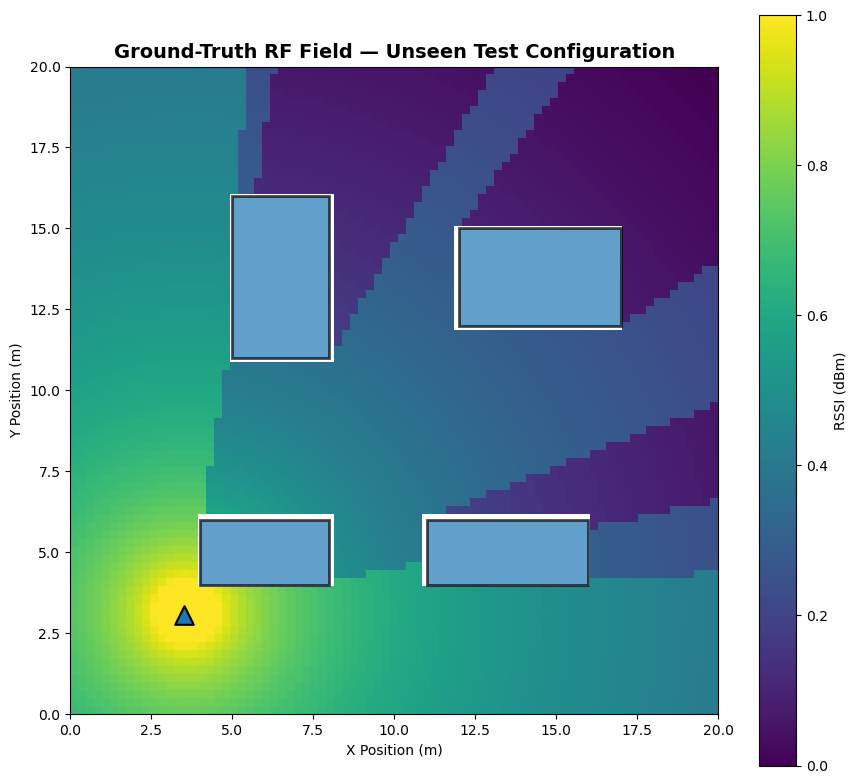

Saved: ML_RFOpt\figures\ground_truth_test_rf_heatmap.png


In [99]:
# GROUND-TRUTH RF HEATMAP

plt.figure(figsize=(9, 8))

plt.imshow(
    actual_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis"
)

plt.scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5
)

for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.colorbar(
    label="RSSI (dBm)"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "Ground-Truth RF Field — Unseen Test Configuration",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "ground_truth_test_rf_heatmap.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

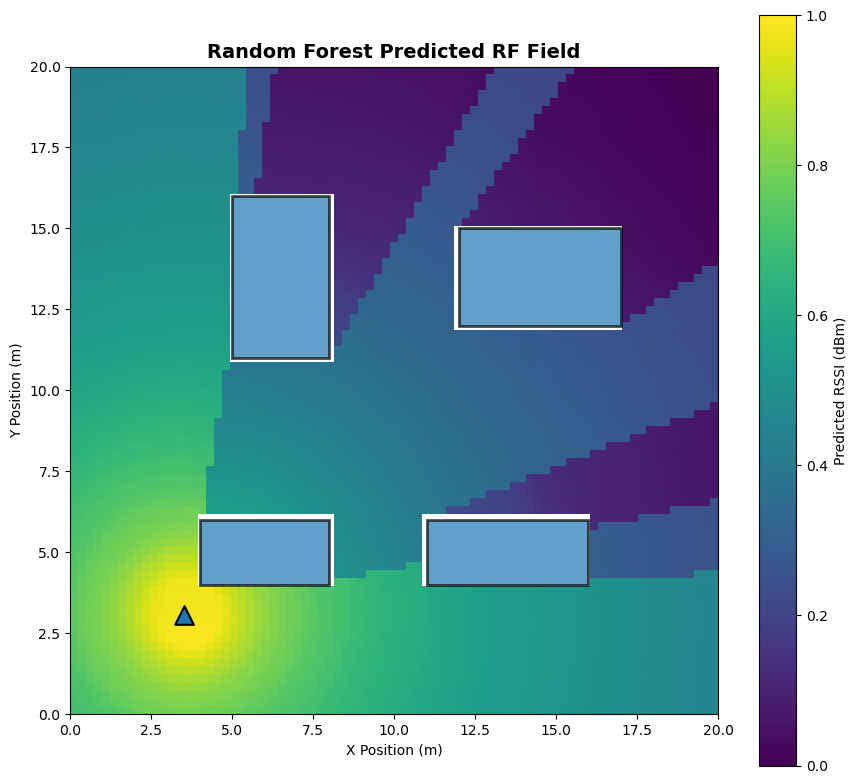

Saved: ML_RFOpt\figures\random_forest_rf_heatmap.png


In [100]:
# RANDOM FOREST PREDICTED RF HEATMAP

plt.figure(figsize=(9, 8))

plt.imshow(
    rf_prediction_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis"
)

plt.scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5
)

for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.colorbar(
    label="Predicted RSSI (dBm)"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "Random Forest Predicted RF Field",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "random_forest_rf_heatmap.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

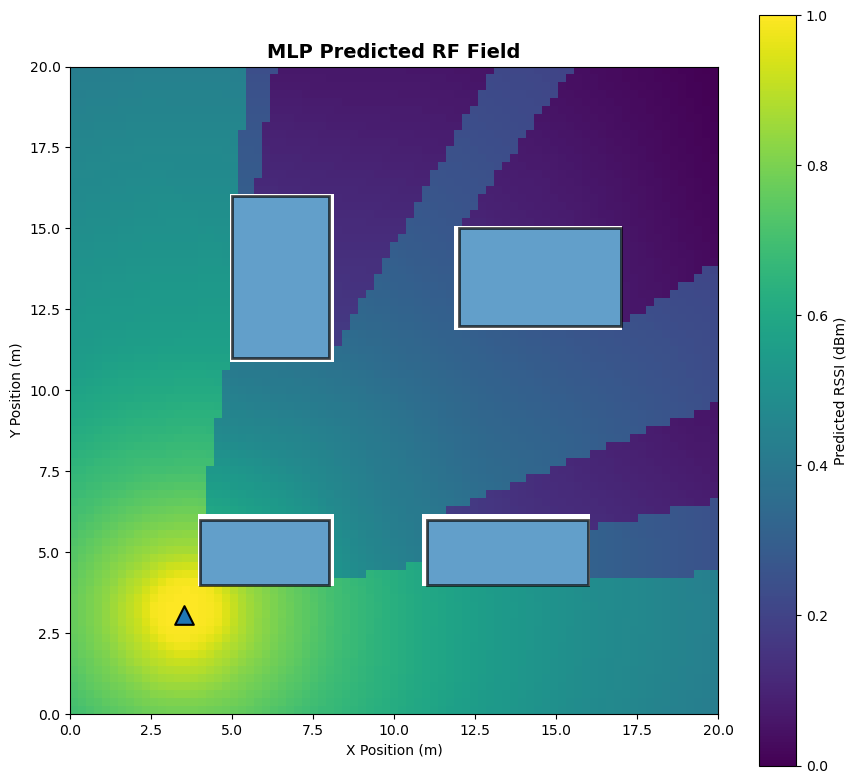

Saved: ML_RFOpt\figures\mlp_rf_heatmap.png


In [101]:
# MLP PREDICTED RF HEATMAP

plt.figure(figsize=(9, 8))

plt.imshow(
    mlp_prediction_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis"
)

plt.scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5
)

for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.colorbar(
    label="Predicted RSSI (dBm)"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "MLP Predicted RF Field",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "mlp_rf_heatmap.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

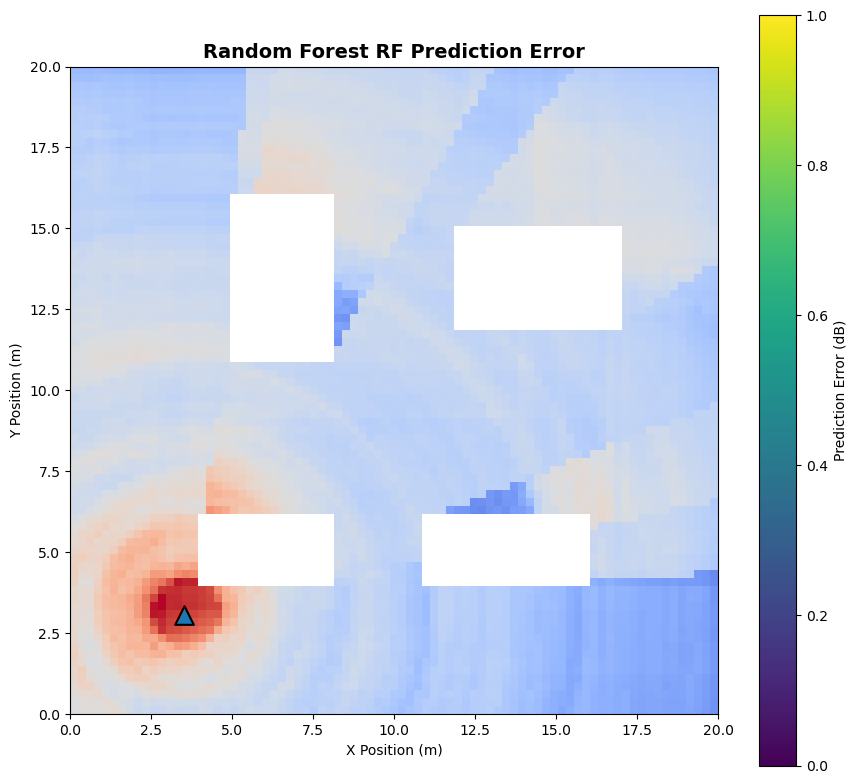

Saved: ML_RFOpt\figures\random_forest_error_heatmap.png


In [102]:
# RANDOM FOREST ERROR MAP

plt.figure(figsize=(9, 8))

maximum_error = np.nanmax(
    np.abs(rf_error_grid)
)

plt.imshow(
    rf_error_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="coolwarm",
    vmin=-maximum_error,
    vmax=maximum_error
)

plt.scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5
)

plt.colorbar(
    label="Prediction Error (dB)"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "Random Forest RF Prediction Error",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "random_forest_error_heatmap.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

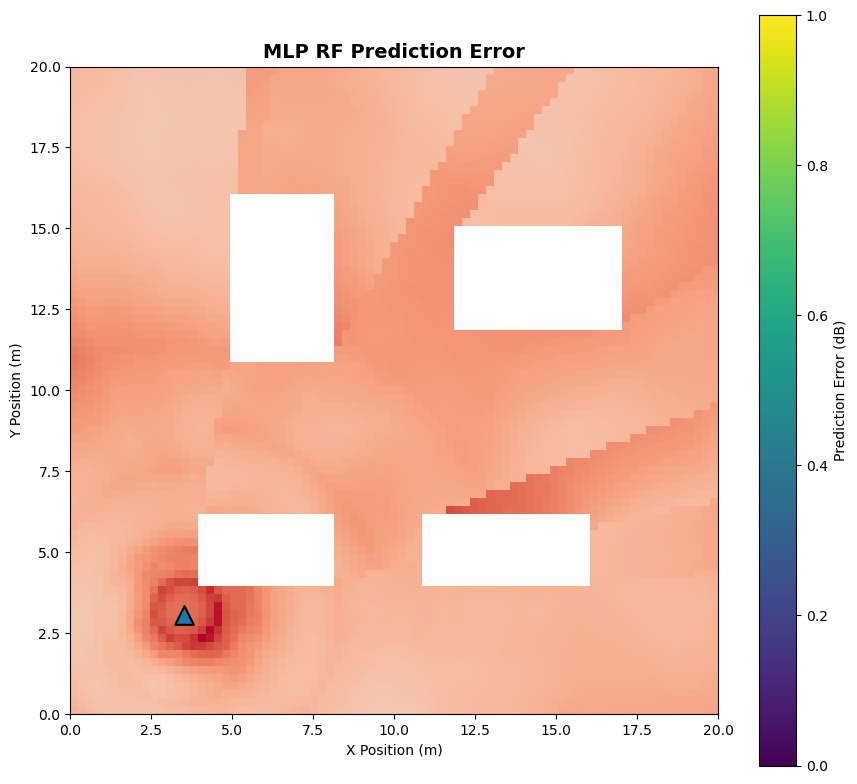

Saved: ML_RFOpt\figures\mlp_error_heatmap.png


In [103]:
# MLP ERROR MAP

plt.figure(figsize=(9, 8))

maximum_error = np.nanmax(
    np.abs(mlp_error_grid)
)

plt.imshow(
    mlp_error_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="coolwarm",
    vmin=-maximum_error,
    vmax=maximum_error
)

plt.scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=180,
    edgecolor="black",
    linewidth=1.5
)

plt.colorbar(
    label="Prediction Error (dB)"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.title(
    "MLP RF Prediction Error",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "mlp_error_heatmap.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [104]:
# FINAL HEATMAP METRICS

spatial_rf_mae = np.nanmean(
    np.abs(rf_error_grid)
)

spatial_mlp_mae = np.nanmean(
    np.abs(mlp_error_grid)
)

spatial_rf_rmse = np.sqrt(
    np.nanmean(
        rf_error_grid ** 2
    )
)

spatial_mlp_rmse = np.sqrt(
    np.nanmean(
        mlp_error_grid ** 2
    )
)

spatial_metrics = pd.DataFrame({
    "Model": [
        "Random Forest",
        "MLP"
    ],
    "Spatial_MAE_dB": [
        spatial_rf_mae,
        spatial_mlp_mae
    ],
    "Spatial_RMSE_dB": [
        spatial_rf_rmse,
        spatial_mlp_rmse
    ]
})

display(
    spatial_metrics.round(4)
)

,Model,Spatial_MAE_dB,Spatial_RMSE_dB
0,Random Forest,0.5181,0.6482
1,MLP,1.3501,1.3926


In [105]:
# SAVE SPATIAL METRICS

spatial_metrics_path = (
    PROJECT_DIR /
    "results" /
    "spatial_heatmap_metrics.csv"
)

spatial_metrics.to_csv(
    spatial_metrics_path,
    index=False
)

print("Saved:")
print(spatial_metrics_path)

Saved:
ML_RFOpt\results\spatial_heatmap_metrics.csv


In [106]:
# FINAL VERIFICATION

print("\nMULTI-CONFIGURATION DATASET")

print(
    "Configurations:",
    multi_config_dataset["config_id"].nunique()
)

print(
    "Samples:",
    len(multi_config_dataset)
)

print(
    "Frequencies:",
    sorted(
        multi_config_dataset[
            "frequency_mhz"
        ].unique()
    )
)

print(
    "Transmit powers:",
    sorted(
        multi_config_dataset[
            "transmit_power_dbm"
        ].unique()
    )
)

print("\nMODEL RESULTS")

display(
    metrics_table.round(4)
)

print("\nUNSEEN TEST CONFIGURATION")

print(
    "Configuration:",
    selected_test_config
)

print(
    "Antenna:",
    (
        TEST_ANTENNA_X,
        TEST_ANTENNA_Y
    )
)

print(
    "Frequency:",
    TEST_FREQUENCY,
    "MHz"
)

print(
    "Transmit power:",
    TEST_POWER,
    "dBm"
)



MULTI-CONFIGURATION DATASET
Configurations: 30
Samples: 170190
Frequencies: [1800.0, 2400.0, 3500.0]
Transmit powers: [15.0, 20.0, 25.0]

MODEL RESULTS


,MAE_dB,RMSE_dB,R2,Mean_Error_dB
Random Forest,1.5840,2.0306,0.9600,-1.1114
MLP,1.0341,1.1839,0.9864,-0.8193



UNSEEN TEST CONFIGURATION
Configuration: 24
Antenna: (3.52, 3.06)
Frequency: 3500.0 MHz
Transmit power: 25.0 dBm


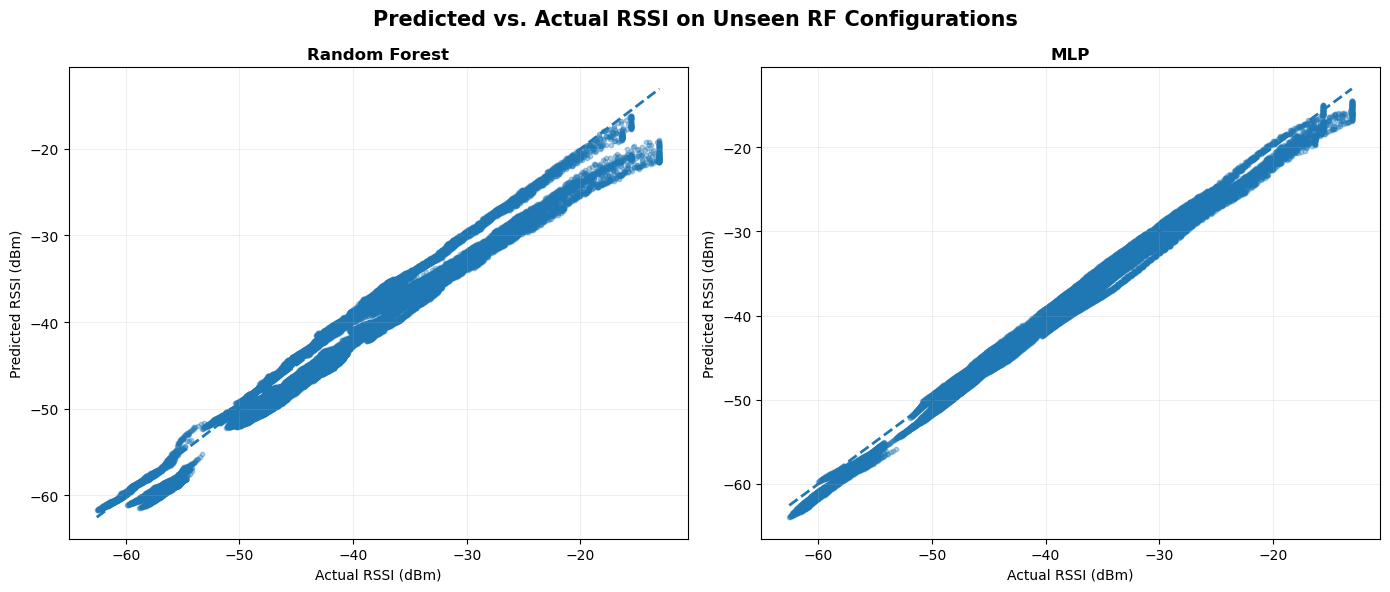

Saved: ML_RFOpt\figures\prediction_comparison.png


In [107]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# RANDOM FOREST

axes[0].scatter(
    y_test,
    rf_test_prediction,
    s=10,
    alpha=0.35
)

min_value = min(
    y_test.min(),
    rf_test_prediction.min()
)

max_value = max(
    y_test.max(),
    rf_test_prediction.max()
)

axes[0].plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

axes[0].set_xlabel(
    "Actual RSSI (dBm)"
)

axes[0].set_ylabel(
    "Predicted RSSI (dBm)"
)

axes[0].set_title(
    "Random Forest",
    fontweight="bold"
)

axes[0].grid(alpha=0.2)

# MLP

axes[1].scatter(
    y_test,
    mlp_test_prediction,
    s=10,
    alpha=0.35
)

axes[1].plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

axes[1].set_xlabel(
    "Actual RSSI (dBm)"
)

axes[1].set_ylabel(
    "Predicted RSSI (dBm)"
)

axes[1].set_title(
    "MLP",
    fontweight="bold"
)

axes[1].grid(alpha=0.2)

plt.suptitle(
    "Predicted vs. Actual RSSI on Unseen RF Configurations",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "prediction_comparison.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

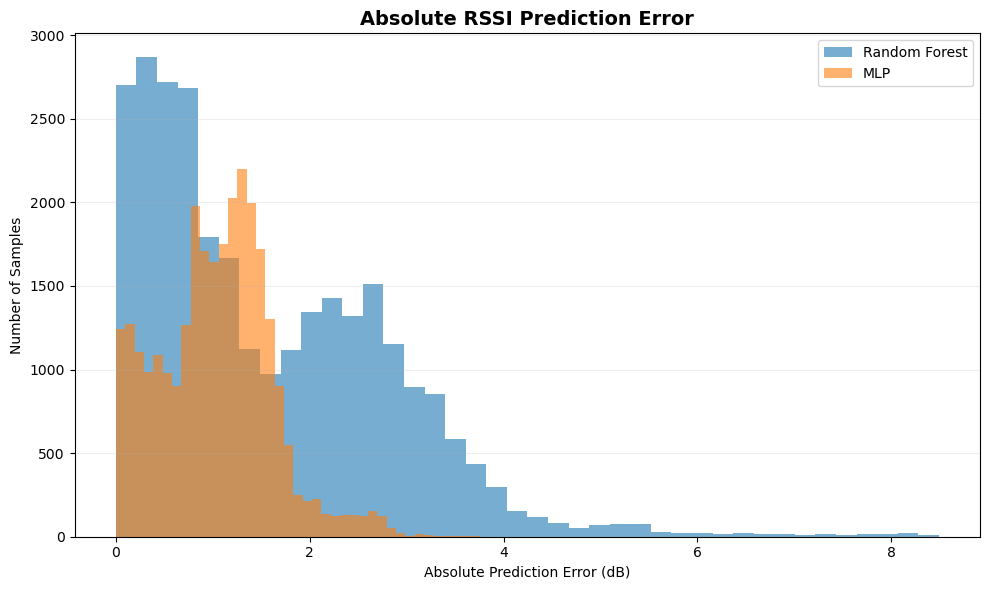

Saved: ML_RFOpt\figures\absolute_error_comparison.png


In [108]:
# ABSOLUTE ERROR COMPARISON

rf_absolute_error = np.abs(
    y_test.values -
    rf_test_prediction
)

mlp_absolute_error = np.abs(
    y_test.values -
    mlp_test_prediction
)

plt.figure(figsize=(10, 6))

plt.hist(
    rf_absolute_error,
    bins=40,
    alpha=0.6,
    label="Random Forest"
)

plt.hist(
    mlp_absolute_error,
    bins=40,
    alpha=0.6,
    label="MLP"
)

plt.xlabel(
    "Absolute Prediction Error (dB)"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "Absolute RSSI Prediction Error",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "absolute_error_comparison.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [109]:
# ERROR STATISTICS

error_summary = pd.DataFrame({
    "Model": [
        "Random Forest",
        "MLP"
    ],

    "Mean_Absolute_Error_dB": [
        np.mean(rf_absolute_error),
        np.mean(mlp_absolute_error)
    ],

    "Median_Absolute_Error_dB": [
        np.median(rf_absolute_error),
        np.median(mlp_absolute_error)
    ],

    "Maximum_Absolute_Error_dB": [
        np.max(rf_absolute_error),
        np.max(mlp_absolute_error)
    ],

    "90th_Percentile_Error_dB": [
        np.percentile(
            rf_absolute_error,
            90
        ),
        np.percentile(
            mlp_absolute_error,
            90
        )
    ]
})

display(
    error_summary.round(4)
)

,Model,Mean_Absolute_Error_dB,Median_Absolute_Error_dB,Maximum_Absolute_Error_dB,90th_Percentile_Error_dB
0,Random Forest,1.5840,1.2421,8.4911,3.241
1,MLP,1.0341,1.0600,3.8519,1.670


In [110]:

# ANTENNA PLACEMENT OPTIMIZATION

COVERAGE_THRESHOLD_DBM = -75.0

WEAK_THRESHOLD_DBM = -80.0

WEIGHT_COVERAGE = 0.60
WEIGHT_MEAN_RSSI = 0.25
WEIGHT_MIN_RSSI = 0.15

OPTIMIZATION_GRID_STEP = 1.0

print(
    "Coverage threshold:",
    COVERAGE_THRESHOLD_DBM,
    "dBm"
)

print(
    "Weak-signal threshold:",
    WEAK_THRESHOLD_DBM,
    "dBm"
)

print(
    "Optimization grid step:",
    OPTIMIZATION_GRID_STEP,
    "m"
)

Coverage threshold: -75.0 dBm
Weak-signal threshold: -80.0 dBm
Optimization grid step: 1.0 m


In [111]:
# GENERATE CANDIDATE ANTENNA LOCATIONS

candidate_positions = []

candidate_x_values = np.arange(
    1.0,
    ROOM_WIDTH,
    OPTIMIZATION_GRID_STEP
)

candidate_y_values = np.arange(
    1.0,
    ROOM_HEIGHT,
    OPTIMIZATION_GRID_STEP
)

for antenna_x in candidate_x_values:

    for antenna_y in candidate_y_values:

        # Antenna cannot be inside an obstacle
        if point_inside_obstacle(
            antenna_x,
            antenna_y
        ):
            continue

        candidate_positions.append(
            (
                round(antenna_x, 2),
                round(antenna_y, 2)
            )
        )

print(
    "Candidate antenna locations:",
    len(candidate_positions)
)

Candidate antenna locations: 280


In [112]:
# OPTIMIZATION RF CONFIGURATION

OPTIMIZATION_FREQUENCY = TEST_FREQUENCY
OPTIMIZATION_POWER = TEST_POWER

print(
    "Optimization frequency:",
    OPTIMIZATION_FREQUENCY,
    "MHz"
)

print(
    "Optimization transmit power:",
    OPTIMIZATION_POWER,
    "dBm"
)

Optimization frequency: 3500.0 MHz
Optimization transmit power: 25.0 dBm


In [113]:
# RECEIVER POINTS FOR OPTIMIZATION

receiver_points = []

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        if obstacle_mask[row, col]:
            continue

        receiver_points.append(
            (
                receiver_x,
                receiver_y
            )
        )

print(
    "Receiver points:",
    len(receiver_points)
)

Receiver points: 5673


In [114]:
# ANTENNA PLACEMENT SEARCH

optimization_records = []

print(
    "Evaluating candidate antenna positions..."
)

for candidate_index, (
    antenna_x,
    antenna_y
) in enumerate(candidate_positions):

    candidate_records = []

    for receiver_x, receiver_y in receiver_points:

        (
            _,
            distance,
            obstacle_count
        ) = calculate_rssi_with_frequency(
            (
                antenna_x,
                antenna_y
            ),
            (
                receiver_x,
                receiver_y
            ),
            OPTIMIZATION_FREQUENCY,
            OPTIMIZATION_POWER
        )

        candidate_records.append({
            "receiver_x_m": receiver_x,
            "receiver_y_m": receiver_y,
            "antenna_x_m": antenna_x,
            "antenna_y_m": antenna_y,
            "distance_m": distance,
            "frequency_mhz": OPTIMIZATION_FREQUENCY,
            "transmit_power_dbm": OPTIMIZATION_POWER,
            "antenna_gain_dbi": ANTENNA_GAIN_DBI,
            "obstacle_count": obstacle_count
        })

    candidate_df = pd.DataFrame(
        candidate_records
    )

    candidate_features = candidate_df[
        FEATURE_COLUMNS
    ]

    # RF prediction
    predicted_rssi = random_forest.predict(
        candidate_features
    )

    # --------------------------------------------------------
    # Calculate coverage statistics
    # --------------------------------------------------------

    coverage_percentage = (
        np.mean(
            predicted_rssi
            >= COVERAGE_THRESHOLD_DBM
        )
        * 100
    )

    weak_percentage = (
        np.mean(
            predicted_rssi
            < WEAK_THRESHOLD_DBM
        )
        * 100
    )

    mean_rssi = np.mean(
        predicted_rssi
    )

    minimum_rssi = np.min(
        predicted_rssi
    )

    # --------------------------------------------------------
    # Normalize metrics
    # --------------------------------------------------------

    normalized_mean_rssi = np.clip(
        (mean_rssi + 100) / 50,
        0,
        1
    )

    normalized_min_rssi = np.clip(
        (minimum_rssi + 100) / 50,
        0,
        1
    )

    normalized_coverage = (
        coverage_percentage / 100
    )

    # --------------------------------------------------------
    # Optimization score
    # --------------------------------------------------------

    score = (
        WEIGHT_COVERAGE *
        normalized_coverage
        +
        WEIGHT_MEAN_RSSI *
        normalized_mean_rssi
        +
        WEIGHT_MIN_RSSI *
        normalized_min_rssi
    )

    optimization_records.append({
        "antenna_x_m": antenna_x,
        "antenna_y_m": antenna_y,
        "coverage_percentage": coverage_percentage,
        "weak_percentage": weak_percentage,
        "mean_rssi_dbm": mean_rssi,
        "minimum_rssi_dbm": minimum_rssi,
        "optimization_score": score
    })

    if (
        candidate_index + 1
    ) % 20 == 0:

        print(
            f"Processed "
            f"{candidate_index + 1}/"
            f"{len(candidate_positions)}"
        )

optimization_results = pd.DataFrame(
    optimization_records
)

print("\nOptimization search completed.")

Evaluating candidate antenna positions...
Processed 20/280
Processed 40/280
Processed 60/280
Processed 80/280
Processed 100/280
Processed 120/280
Processed 140/280
Processed 160/280
Processed 180/280
Processed 200/280
Processed 220/280
Processed 240/280
Processed 260/280
Processed 280/280

Optimization search completed.


In [115]:
# RANK ANTENNA LOCATIONS

optimization_results = (
    optimization_results
    .sort_values(
        "optimization_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top antenna configurations:"
)

display(
    optimization_results.head(10).round(4)
)

Top antenna configurations:


,antenna_x_m,antenna_y_m,coverage_percentage,weak_percentage,mean_rssi_dbm,minimum_rssi_dbm,optimization_score
0,13.0,10.0,100.0,0.0,-39.4481,-50.0177,0.9999
1,11.0,10.0,100.0,0.0,-39.7983,-50.5453,0.9984
2,10.0,10.0,100.0,0.0,-39.7692,-50.6671,0.9980
3,11.0,11.0,100.0,0.0,-39.8995,-50.6968,0.9979
4,12.0,11.0,100.0,0.0,-40.3123,-50.8327,0.9975
5,13.0,9.0,100.0,0.0,-40.0684,-50.8968,0.9973
6,12.0,10.0,100.0,0.0,-40.2382,-51.0676,0.9968
7,10.0,11.0,100.0,0.0,-39.8649,-51.0679,0.9968
8,9.0,10.0,100.0,0.0,-39.7888,-51.1436,0.9966
9,13.0,8.0,100.0,0.0,-40.3033,-51.1643,0.9965


In [117]:
# BEST ANTENNA POSITION

best_solution = (
    optimization_results.iloc[0]
)

OPTIMAL_ANTENNA_X = (
    best_solution["antenna_x_m"]
)

OPTIMAL_ANTENNA_Y = (
    best_solution["antenna_y_m"]
)

print("OPTIMAL ANTENNA LOCATION")

print(
    "X:",
    OPTIMAL_ANTENNA_X,
    "m"
)

print(
    "Y:",
    OPTIMAL_ANTENNA_Y,
    "m"
)

print(
    "Coverage:",
    round(
        best_solution[
            "coverage_percentage"
        ],
        2
    ),
    "%"
)

print(
    "Mean RSSI:",
    round(
        best_solution[
            "mean_rssi_dbm"
        ],
        2
    ),
    "dBm"
)

print(
    "Minimum RSSI:",
    round(
        best_solution[
            "minimum_rssi_dbm"
        ],
        2
    ),
    "dBm"
)

print(
    "Optimization score:",
    round(
        best_solution[
            "optimization_score"
        ],
        4
    )
)

OPTIMAL ANTENNA LOCATION
X: 13.0 m
Y: 10.0 m
Coverage: 100.0 %
Mean RSSI: -39.45 dBm
Minimum RSSI: -50.02 dBm
Optimization score: 0.9999


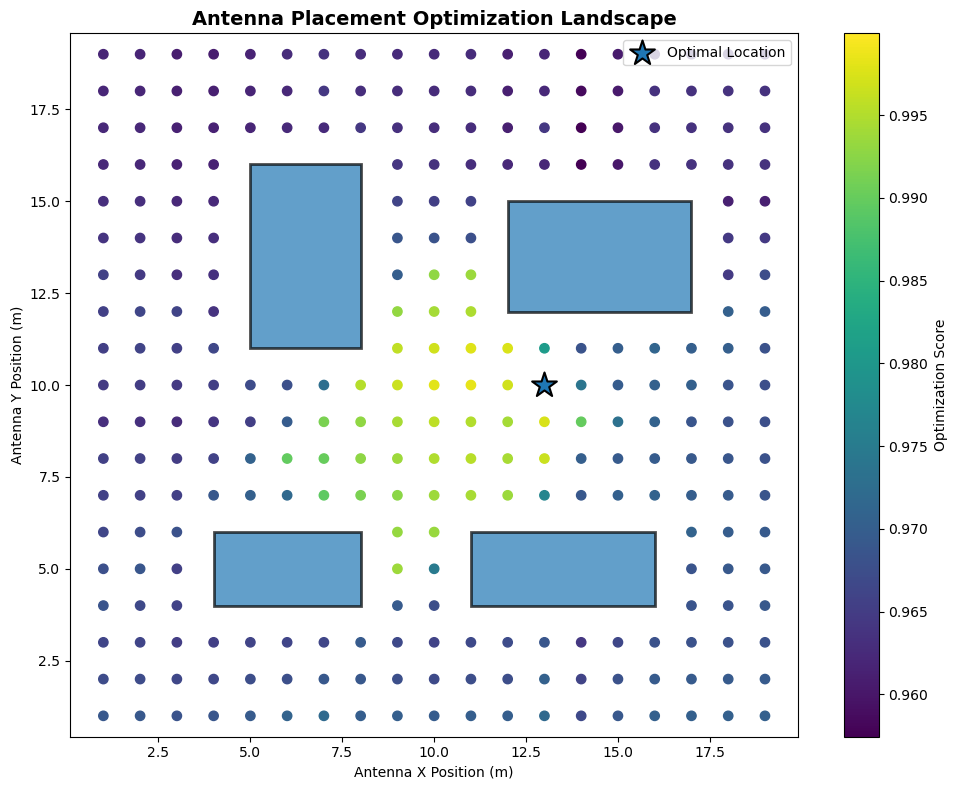

Saved: ML_RFOpt\figures\antenna_optimization_landscape.png


In [118]:
# OPTIMIZATION LANDSCAPE

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    optimization_results["antenna_x_m"],
    optimization_results["antenna_y_m"],
    c=optimization_results["optimization_score"],
    s=45,
    cmap="viridis"
)

plt.scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=350,
    edgecolor="black",
    linewidth=1.5,
    label="Optimal Location"
)

for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.colorbar(
    scatter,
    label="Optimization Score"
)

plt.xlabel("Antenna X Position (m)")
plt.ylabel("Antenna Y Position (m)")

plt.title(
    "Antenna Placement Optimization Landscape",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.axis("equal")

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "antenna_optimization_landscape.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

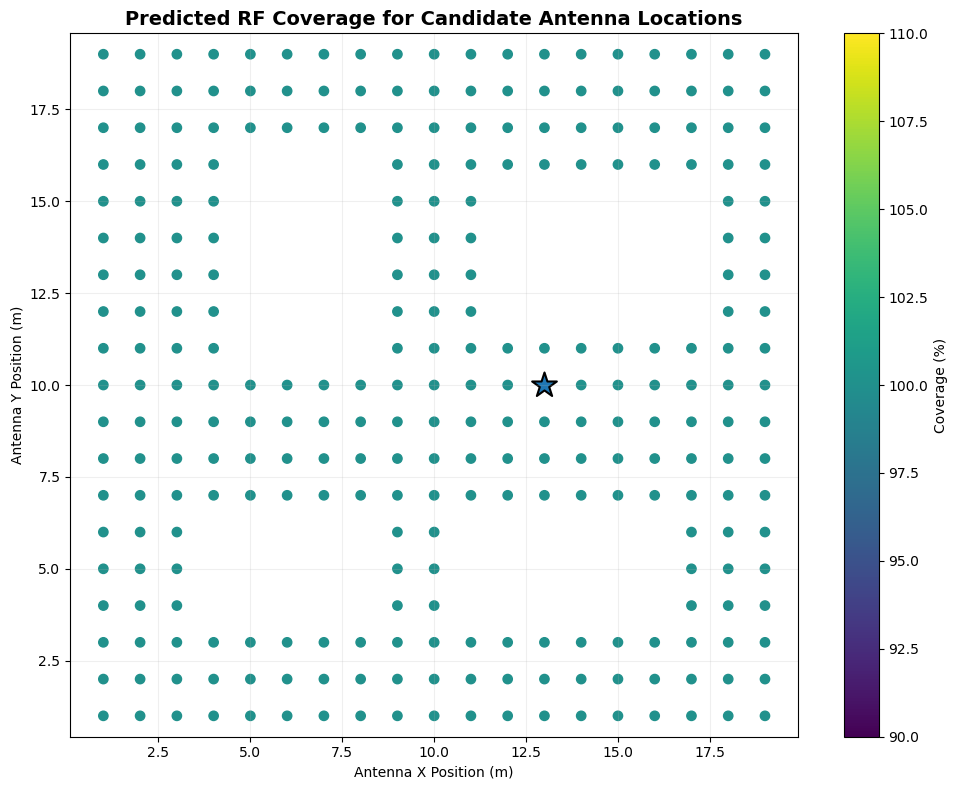

Saved: ML_RFOpt\figures\antenna_coverage_optimization.png


In [119]:
# COVERAGE OPTIMIZATION MAP

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    optimization_results["antenna_x_m"],
    optimization_results["antenna_y_m"],
    c=optimization_results[
        "coverage_percentage"
    ],
    s=45,
    cmap="viridis"
)

plt.scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=350,
    edgecolor="black",
    linewidth=1.5
)

plt.colorbar(
    scatter,
    label="Coverage (%)"
)

plt.xlabel(
    "Antenna X Position (m)"
)

plt.ylabel(
    "Antenna Y Position (m)"
)

plt.title(
    "Predicted RF Coverage for Candidate Antenna Locations",
    fontsize=14,
    fontweight="bold"
)

plt.axis("equal")
plt.grid(alpha=0.2)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "antenna_coverage_optimization.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [120]:
# SAVE OPTIMIZATION RESULTS

optimization_results_path = (
    PROJECT_DIR /
    "results" /
    "antenna_optimization_results.csv"
)

optimization_results.to_csv(
    optimization_results_path,
    index=False
)

print(
    "Optimization results saved:"
)

print(
    optimization_results_path
)

Optimization results saved:
ML_RFOpt\results\antenna_optimization_results.csv


In [122]:
# FINAL OPTIMIZED RF FIELD

optimal_rssi_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        if obstacle_mask[row, col]:
            continue

        (
            _,
            distance,
            obstacle_count
        ) = calculate_rssi_with_frequency(
            (
                OPTIMAL_ANTENNA_X,
                OPTIMAL_ANTENNA_Y
            ),
            (
                receiver_x,
                receiver_y
            ),
            OPTIMIZATION_FREQUENCY,
            OPTIMIZATION_POWER
        )

        input_record = pd.DataFrame([{
            "receiver_x_m": receiver_x,
            "receiver_y_m": receiver_y,
            "antenna_x_m": OPTIMAL_ANTENNA_X,
            "antenna_y_m": OPTIMAL_ANTENNA_Y,
            "distance_m": distance,
            "frequency_mhz": OPTIMIZATION_FREQUENCY,
            "transmit_power_dbm": OPTIMIZATION_POWER,
            "antenna_gain_dbi": ANTENNA_GAIN_DBI,
            "obstacle_count": obstacle_count
        }])

        predicted_rssi = (
            random_forest.predict(
                input_record[
                    FEATURE_COLUMNS
                ]
            )[0]
        )

        optimal_rssi_grid[
            row,
            col
        ] = predicted_rssi

print(
    "Optimized RF field generated."
)

Optimized RF field generated.


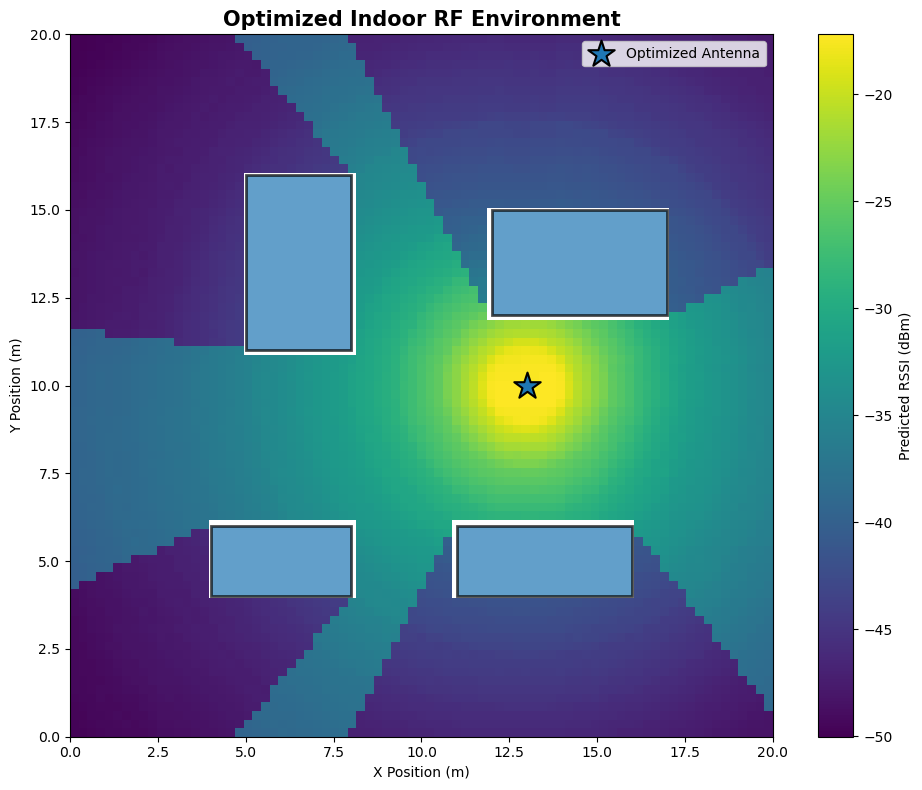

Saved: ML_RFOpt\figures\final_optimized_rf_map.png


In [123]:
# FINAL OPTIMIZED RF HEATMAP

plt.figure(figsize=(10, 8))

heatmap = plt.imshow(
    optimal_rssi_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis"
)

# Optimal antenna
plt.scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=400,
    edgecolor="black",
    linewidth=1.5,
    label="Optimized Antenna"
)

# Obstacles
for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(rectangle)

plt.colorbar(
    heatmap,
    label="Predicted RSSI (dBm)"
)

plt.xlabel(
    "X Position (m)"
)

plt.ylabel(
    "Y Position (m)"
)

plt.title(
    "Optimized Indoor RF Environment",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    loc="upper right"
)

plt.tight_layout()

path = (
    PROJECT_DIR /
    "figures" /
    "final_optimized_rf_map.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    path
)

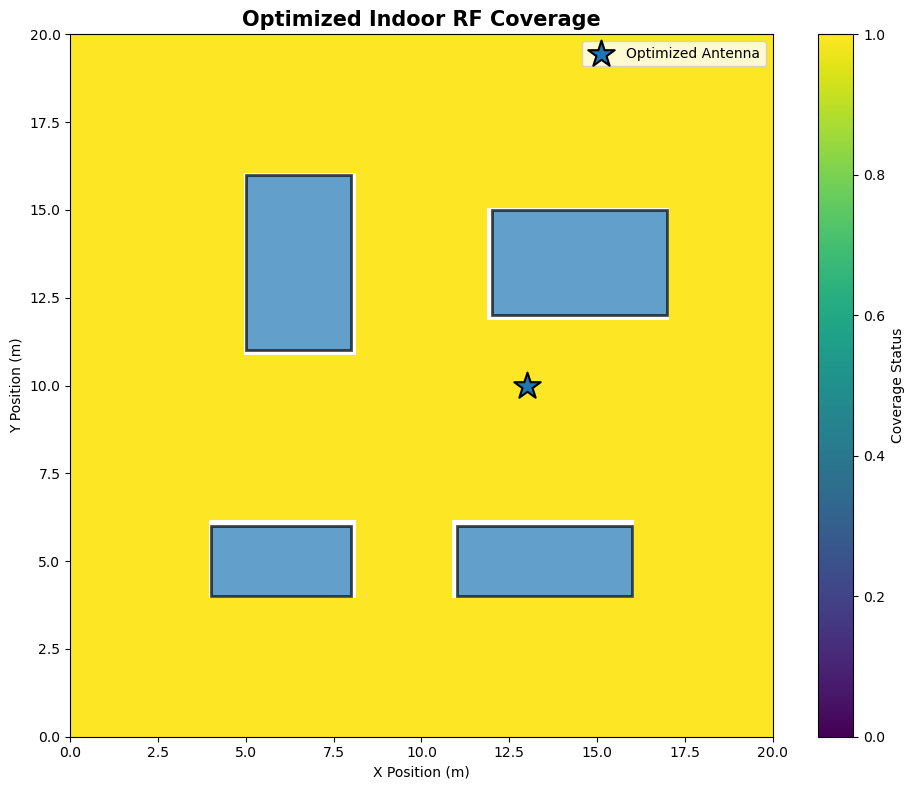

Saved: ML_RFOpt\figures\final_rf_coverage_map.png


In [125]:
# COVERAGE MAP

coverage_map = np.where(
    optimal_rssi_grid >= COVERAGE_THRESHOLD_DBM,
    1.0,
    0.0
).astype(float)

coverage_map[
    np.isnan(optimal_rssi_grid)
] = np.nan

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    coverage_map,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis",
    vmin=0,
    vmax=1
)


plt.scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=400,
    edgecolor="black",
    linewidth=1.5,
    label="Optimized Antenna"
)


for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=2,
        alpha=0.7
    )

    plt.gca().add_patch(
        rectangle
    )


plt.xlabel(
    "X Position (m)"
)

plt.ylabel(
    "Y Position (m)"
)

plt.title(
    "Optimized Indoor RF Coverage",
    fontsize=15,
    fontweight="bold"
)


colorbar = plt.colorbar()

colorbar.set_label(
    "Coverage Status"
)


plt.legend(
    loc="upper right"
)

plt.tight_layout()


path = (
    PROJECT_DIR /
    "figures" /
    "final_rf_coverage_map.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    path
)

In [126]:
# OPTIMIZATION STATISTICS

valid_rssi = optimal_rssi_grid[
    ~np.isnan(optimal_rssi_grid)
]

final_coverage = (
    np.mean(
        valid_rssi >= COVERAGE_THRESHOLD_DBM
    ) * 100
)

final_weak_percentage = (
    np.mean(
        valid_rssi < WEAK_THRESHOLD_DBM
    ) * 100
)

final_mean_rssi = np.mean(
    valid_rssi
)

final_min_rssi = np.min(
    valid_rssi
)

final_max_rssi = np.max(
    valid_rssi
)

final_results = pd.DataFrame({
    "Metric": [
        "Optimal Antenna X (m)",
        "Optimal Antenna Y (m)",
        "Frequency (MHz)",
        "Transmit Power (dBm)",
        "Coverage (%)",
        "Weak Signal (%)",
        "Mean RSSI (dBm)",
        "Minimum RSSI (dBm)",
        "Maximum RSSI (dBm)"
    ],

    "Value": [
        OPTIMAL_ANTENNA_X,
        OPTIMAL_ANTENNA_Y,
        OPTIMIZATION_FREQUENCY,
        OPTIMIZATION_POWER,
        final_coverage,
        final_weak_percentage,
        final_mean_rssi,
        final_min_rssi,
        final_max_rssi
    ]
})

display(
    final_results.round(4)
)

,Metric,Value
0,Optimal Antenna X (m),13.0000
1,Optimal Antenna Y (m),10.0000
2,Frequency (MHz),3500.0000
3,Transmit Power (dBm),25.0000
4,Coverage (%),100.0000
5,Weak Signal (%),0.0000
6,Mean RSSI (dBm),-39.4481
7,Minimum RSSI (dBm),-50.0177
8,Maximum RSSI (dBm),-17.2055


In [127]:
# SAVE OPTIMIZATION SUMMARY

final_results_path = (
    PROJECT_DIR /
    "results" /
    "final_optimization_summary.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print(
    "Final optimization summary saved:"
)

print(
    final_results_path
)

Final optimization summary saved:
ML_RFOpt\results\final_optimization_summary.csv


In [128]:
# PROJECT SUMMARY

print("ML-RFOpt — FINAL EXPERIMENTAL SUMMARY")

print("\nMODEL")

print(
    "Random Forest MAE:",
    round(
        rf_metrics["MAE_dB"],
        4
    ),
    "dB"
)

print(
    "Random Forest RMSE:",
    round(
        rf_metrics["RMSE_dB"],
        4
    ),
    "dB"
)

print(
    "Random Forest R²:",
    round(
        rf_metrics["R2"],
        4
    )
)

print(
    "\nMLP MAE:",
    round(
        mlp_metrics["MAE_dB"],
        4
    ),
    "dB"
)

print(
    "MLP RMSE:",
    round(
        mlp_metrics["RMSE_dB"],
        4
    ),
    "dB"
)

print(
    "MLP R²:",
    round(
        mlp_metrics["R2"],
        4
    )
)

print("\nOPTIMIZATION")

print(
    "Optimal antenna:",
    (
        OPTIMAL_ANTENNA_X,
        OPTIMAL_ANTENNA_Y
    ),
    "m"
)

print(
    "Final coverage:",
    round(
        final_coverage,
        2
    ),
    "%"
)

print(
    "Weak-signal area:",
    round(
        final_weak_percentage,
        2
    ),
    "%"
)

print(
    "Mean RSSI:",
    round(
        final_mean_rssi,
        2
    ),
    "dBm"
)

print(
    "Minimum RSSI:",
    round(
        final_min_rssi,
        2
    ),
    "dBm"
)


ML-RFOpt — FINAL EXPERIMENTAL SUMMARY

MODEL
Random Forest MAE: 1.584 dB
Random Forest RMSE: 2.0306 dB
Random Forest R²: 0.96

MLP MAE: 1.0341 dB
MLP RMSE: 1.1839 dB
MLP R²: 0.9864

OPTIMIZATION
Optimal antenna: (13.0, 10.0) m
Final coverage: 100.0 %
Weak-signal area: 0.0 %
Mean RSSI: -39.45 dBm
Minimum RSSI: -50.02 dBm


In [129]:

PUBLICATION_FIGURE_DIR = (
    PROJECT_DIR /
    "figures" /
    "publication"
)

PUBLICATION_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8
})

print(
    "Publication figure directory:"
)

print(
    PUBLICATION_FIGURE_DIR
)

Publication figure directory:
ML_RFOpt\figures\publication


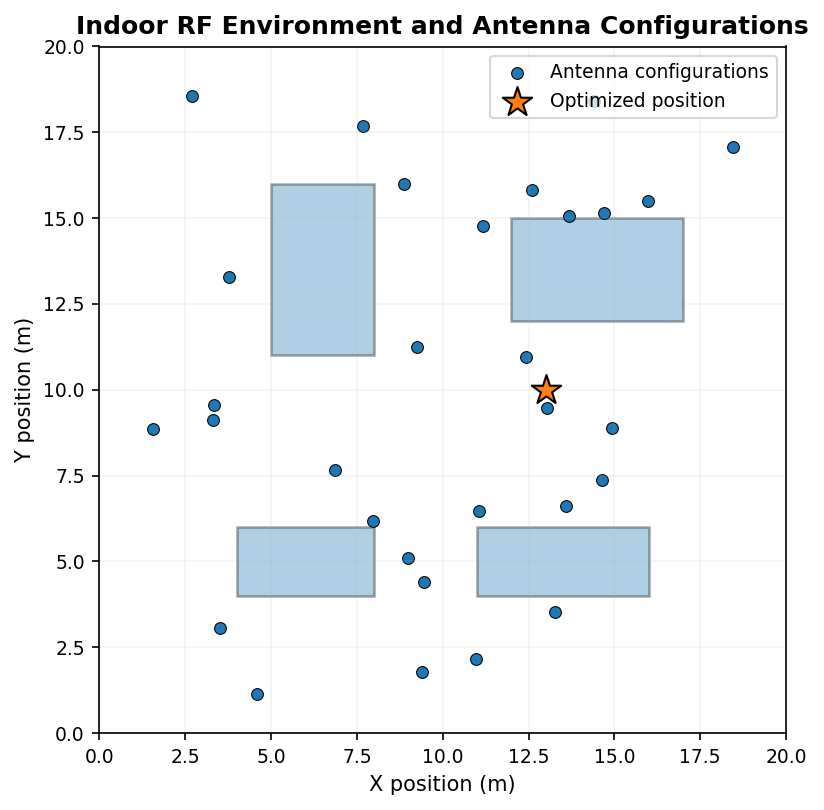

Saved:
ML_RFOpt\figures\publication\Fig1_indoor_environment_configurations.png
ML_RFOpt\figures\publication\Fig1_indoor_environment_configurations.pdf


In [130]:
# INDOOR ENVIRONMENT AND ANTENNA CONFIGURATIONS

fig, ax = plt.subplots(
    figsize=(7.0, 5.5)
)

# Draw obstacles
for (
    x_min,
    y_min,
    x_max,
    y_max
) in OBSTACLES:

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=True,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.35
    )

    ax.add_patch(rectangle)

# Antenna configurations
ax.scatter(
    configuration_table["antenna_x_m"],
    configuration_table["antenna_y_m"],
    s=32,
    edgecolor="black",
    linewidth=0.5,
    label="Antenna configurations"
)

# Optimal antenna
ax.scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=220,
    edgecolor="black",
    linewidth=1.0,
    label="Optimized position"
)

ax.set_xlim(
    0,
    ROOM_WIDTH
)

ax.set_ylim(
    0,
    ROOM_HEIGHT
)

ax.set_xlabel(
    "X position (m)"
)

ax.set_ylabel(
    "Y position (m)"
)

ax.set_title(
    "Indoor RF Environment and Antenna Configurations",
    fontweight="bold"
)

ax.legend(
    loc="upper right",
    frameon=True
)

ax.set_aspect(
    "equal"
)

ax.grid(
    alpha=0.15
)

plt.tight_layout()

figure1_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig1_indoor_environment_configurations.png"
)

plt.savefig(
    figure1_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure1_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure1_path)
print(figure1_path.with_suffix(".pdf"))

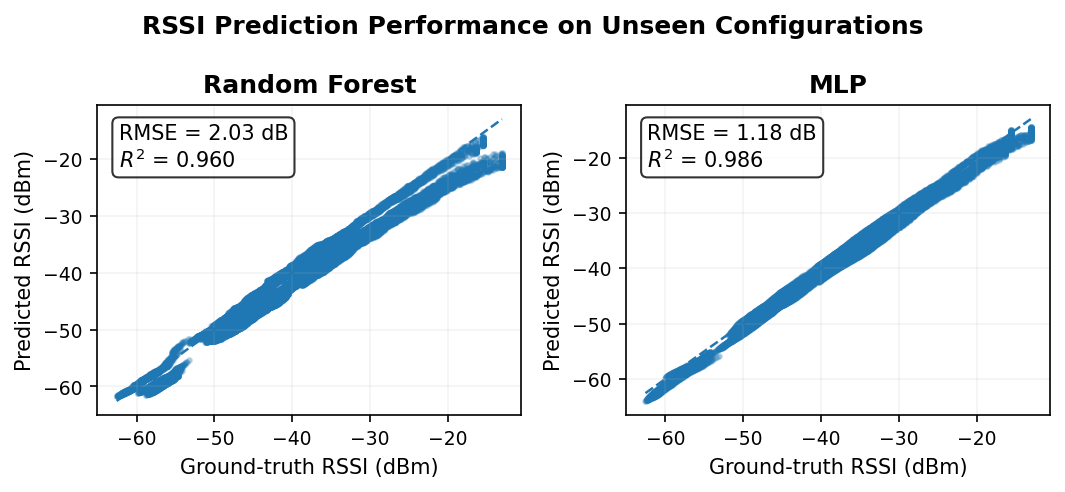

Saved:
ML_RFOpt\figures\publication\Fig2_model_prediction_performance.png


In [131]:
# MODEL PREDICTION PERFORMANCE

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.3)
)

# Random Forest

axes[0].scatter(
    y_test,
    rf_test_prediction,
    s=5,
    alpha=0.25,
    rasterized=True
)

min_value = min(
    y_test.min(),
    rf_test_prediction.min()
)

max_value = max(
    y_test.max(),
    rf_test_prediction.max()
)

axes[0].plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.2
)

axes[0].set_xlabel(
    "Ground-truth RSSI (dBm)"
)

axes[0].set_ylabel(
    "Predicted RSSI (dBm)"
)

axes[0].set_title(
    "Random Forest",
    fontweight="bold"
)

axes[0].text(
    0.05,
    0.94,
    f"RMSE = {rf_metrics['RMSE_dB']:.2f} dB\n"
    f"$R^2$ = {rf_metrics['R2']:.3f}",
    transform=axes[0].transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

axes[0].grid(
    alpha=0.15
)

# MLP

axes[1].scatter(
    y_test,
    mlp_test_prediction,
    s=5,
    alpha=0.25,
    rasterized=True
)

axes[1].plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.2
)

axes[1].set_xlabel(
    "Ground-truth RSSI (dBm)"
)

axes[1].set_ylabel(
    "Predicted RSSI (dBm)"
)

axes[1].set_title(
    "MLP",
    fontweight="bold"
)

axes[1].text(
    0.05,
    0.94,
    f"RMSE = {mlp_metrics['RMSE_dB']:.2f} dB\n"
    f"$R^2$ = {mlp_metrics['R2']:.3f}",
    transform=axes[1].transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

axes[1].grid(
    alpha=0.15
)

fig.suptitle(
    "RSSI Prediction Performance on Unseen Configurations",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

figure2_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig2_model_prediction_performance.png"
)

plt.savefig(
    figure2_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure2_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure2_path)

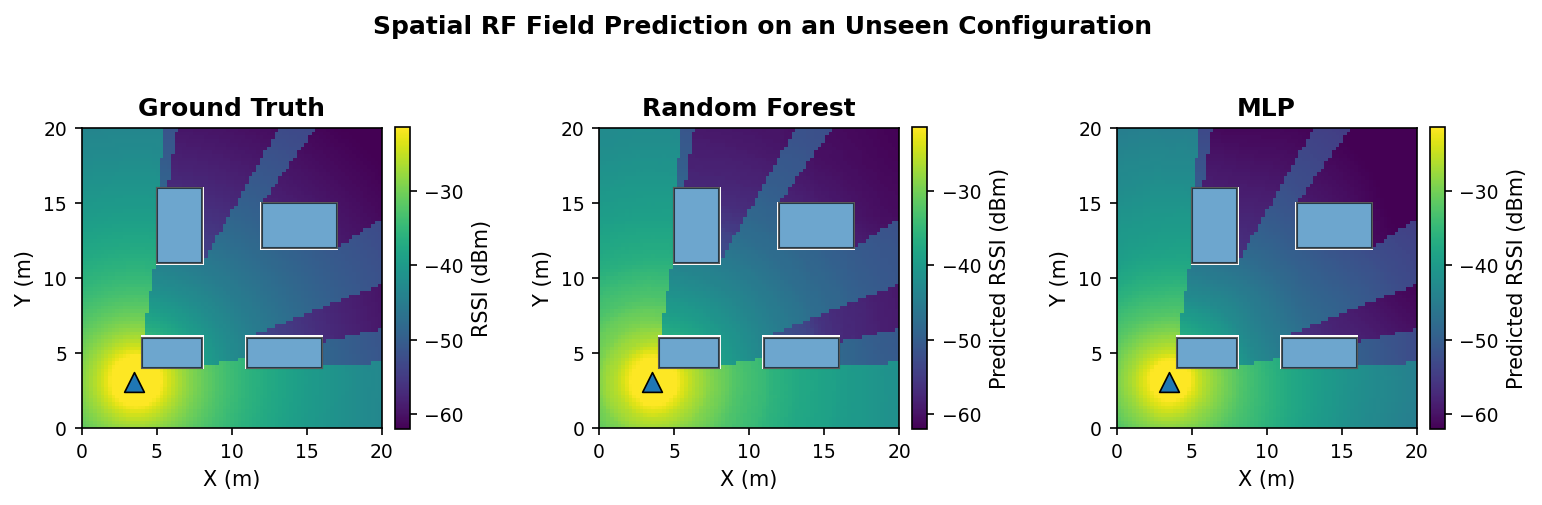

Saved:
ML_RFOpt\figures\publication\Fig3_spatial_rf_prediction_comparison.png


In [132]:
# RF FIELD COMPARISON

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10.5, 3.5)
)

maps = [
    actual_grid,
    rf_prediction_grid,
    mlp_prediction_grid
]

titles = [
    "Ground Truth",
    "Random Forest",
    "MLP"
]

labels = [
    "RSSI (dBm)",
    "Predicted RSSI (dBm)",
    "Predicted RSSI (dBm)"
]

# Use common color scale
valid_values = np.concatenate([
    arr[~np.isnan(arr)].ravel()
    for arr in maps
])

vmin = np.percentile(
    valid_values,
    2
)

vmax = np.percentile(
    valid_values,
    98
)

for ax, data, title, cbar_label in zip(
    axes,
    maps,
    titles,
    labels
):

    image = ax.imshow(
        data,
        origin="lower",
        extent=[
            0,
            ROOM_WIDTH,
            0,
            ROOM_HEIGHT
        ],
        aspect="equal",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        TEST_ANTENNA_X,
        TEST_ANTENNA_Y,
        marker="^",
        s=90,
        edgecolor="black",
        linewidth=0.8
    )

    for (
        x_min,
        y_min,
        x_max,
        y_max
    ) in OBSTACLES:

        rectangle = plt.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            fill=True,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.65
        )

        ax.add_patch(rectangle)

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label=cbar_label
    )

fig.suptitle(
    "Spatial RF Field Prediction on an Unseen Configuration",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

figure3_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig3_spatial_rf_prediction_comparison.png"
)

plt.savefig(
    figure3_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure3_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure3_path)

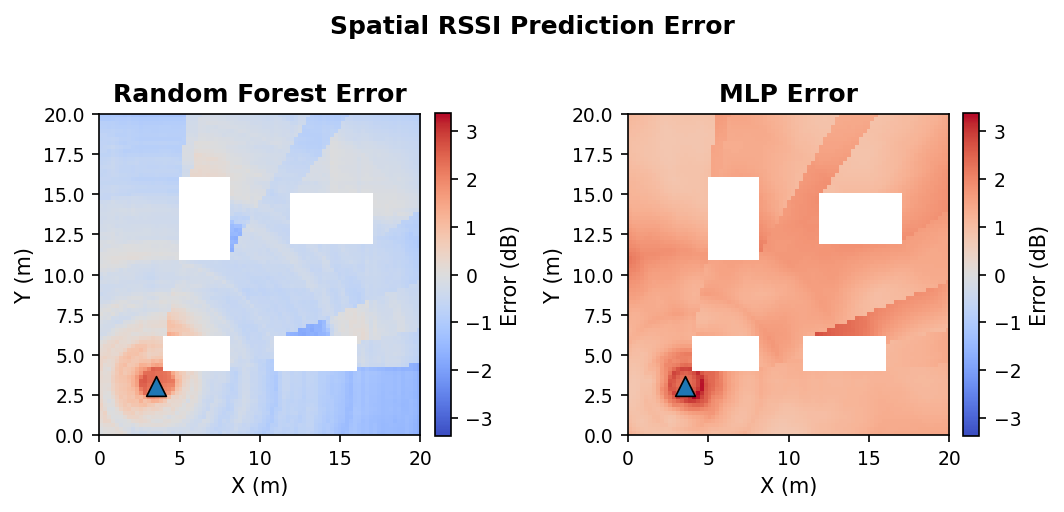

Saved:
ML_RFOpt\figures\publication\Fig4_spatial_prediction_error.png


In [133]:
# SPATIAL PREDICTION ERROR

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.5)
)

error_maps = [
    rf_error_grid,
    mlp_error_grid
]

error_titles = [
    "Random Forest Error",
    "MLP Error"
]

maximum_error = max(
    np.nanmax(
        np.abs(rf_error_grid)
    ),
    np.nanmax(
        np.abs(mlp_error_grid)
    )
)

for ax, error_map, title in zip(
    axes,
    error_maps,
    error_titles
):

    image = ax.imshow(
        error_map,
        origin="lower",
        extent=[
            0,
            ROOM_WIDTH,
            0,
            ROOM_HEIGHT
        ],
        aspect="equal",
        cmap="coolwarm",
        vmin=-maximum_error,
        vmax=maximum_error
    )

    ax.scatter(
        TEST_ANTENNA_X,
        TEST_ANTENNA_Y,
        marker="^",
        s=90,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label="Error (dB)"
    )

fig.suptitle(
    "Spatial RSSI Prediction Error",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

figure4_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig4_spatial_prediction_error.png"
)

plt.savefig(
    figure4_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure4_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure4_path)

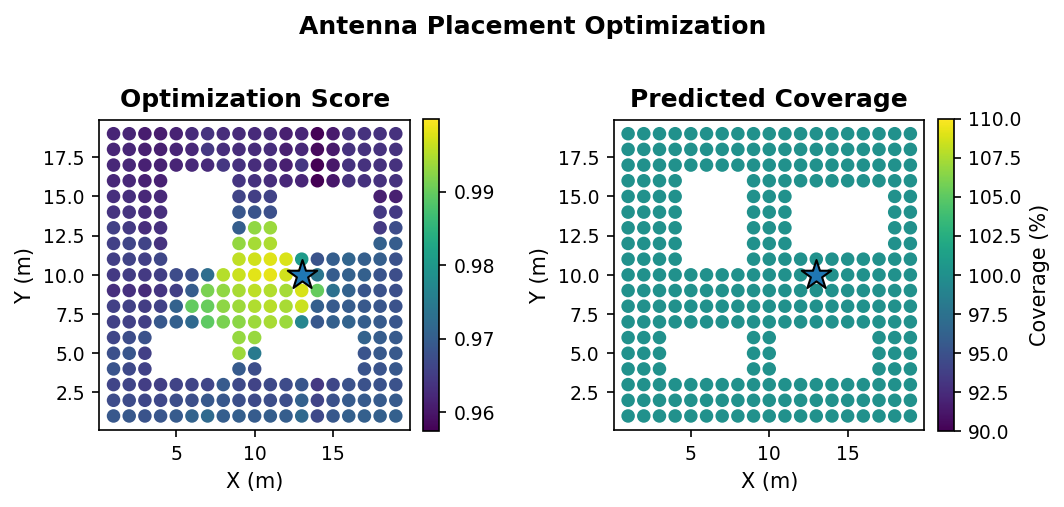

Saved:
ML_RFOpt\figures\publication\Fig5_antenna_placement_optimization.png


In [134]:
# ANTENNA PLACEMENT OPTIMIZATION

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.5)
)

# Optimization score

scatter1 = axes[0].scatter(
    optimization_results["antenna_x_m"],
    optimization_results["antenna_y_m"],
    c=optimization_results[
        "optimization_score"
    ],
    s=30,
    cmap="viridis"
)

axes[0].scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=220,
    edgecolor="black",
    linewidth=1.0
)

axes[0].set_title(
    "Optimization Score",
    fontweight="bold"
)

axes[0].set_xlabel(
    "X (m)"
)

axes[0].set_ylabel(
    "Y (m)"
)

axes[0].set_aspect(
    "equal"
)

fig.colorbar(
    scatter1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)


# Coverage

scatter2 = axes[1].scatter(
    optimization_results["antenna_x_m"],
    optimization_results["antenna_y_m"],
    c=optimization_results[
        "coverage_percentage"
    ],
    s=30,
    cmap="viridis"
)

axes[1].scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=220,
    edgecolor="black",
    linewidth=1.0
)

axes[1].set_title(
    "Predicted Coverage",
    fontweight="bold"
)

axes[1].set_xlabel(
    "X (m)"
)

axes[1].set_ylabel(
    "Y (m)"
)

axes[1].set_aspect(
    "equal"
)

fig.colorbar(
    scatter2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Coverage (%)"
)

fig.suptitle(
    "Antenna Placement Optimization",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

figure5_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig5_antenna_placement_optimization.png"
)

plt.savefig(
    figure5_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure5_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure5_path)

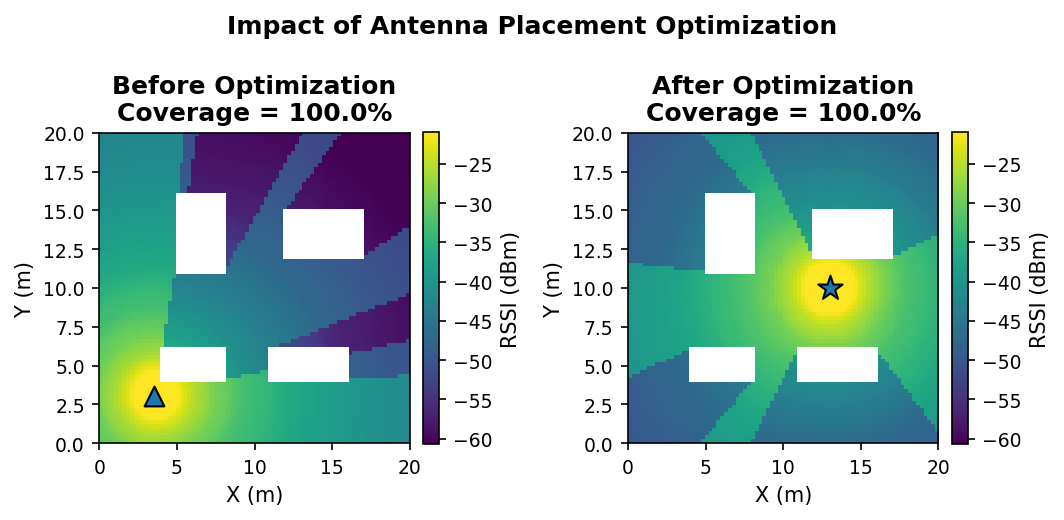

Saved:
ML_RFOpt\figures\publication\Fig6_before_after_optimization.png


In [135]:
# BEFORE VS AFTER ANTENNA OPTIMIZATION

baseline_rssi_grid = np.full_like(
    X,
    np.nan,
    dtype=float
)

for row in range(X.shape[0]):

    for col in range(X.shape[1]):

        receiver_x = X[row, col]
        receiver_y = Y[row, col]

        if obstacle_mask[row, col]:
            continue

        (
            _,
            distance,
            obstacle_count
        ) = calculate_rssi_with_frequency(
            (
                TEST_ANTENNA_X,
                TEST_ANTENNA_Y
            ),
            (
                receiver_x,
                receiver_y
            ),
            OPTIMIZATION_FREQUENCY,
            OPTIMIZATION_POWER
        )

        input_record = pd.DataFrame([{
            "receiver_x_m": receiver_x,
            "receiver_y_m": receiver_y,
            "antenna_x_m": TEST_ANTENNA_X,
            "antenna_y_m": TEST_ANTENNA_Y,
            "distance_m": distance,
            "frequency_mhz": OPTIMIZATION_FREQUENCY,
            "transmit_power_dbm": OPTIMIZATION_POWER,
            "antenna_gain_dbi": ANTENNA_GAIN_DBI,
            "obstacle_count": obstacle_count
        }])

        baseline_rssi_grid[
            row,
            col
        ] = random_forest.predict(
            input_record[
                FEATURE_COLUMNS
            ]
        )[0]


# Calculate baseline statistics

baseline_valid = baseline_rssi_grid[
    ~np.isnan(baseline_rssi_grid)
]

optimized_valid = optimal_rssi_grid[
    ~np.isnan(optimal_rssi_grid)
]

baseline_coverage = (
    np.mean(
        baseline_valid >=
        COVERAGE_THRESHOLD_DBM
    ) * 100
)

optimized_coverage = (
    np.mean(
        optimized_valid >=
        COVERAGE_THRESHOLD_DBM
    ) * 100
)

baseline_mean = np.mean(
    baseline_valid
)

optimized_mean = np.mean(
    optimized_valid
)

baseline_weak = (
    np.mean(
        baseline_valid <
        WEAK_THRESHOLD_DBM
    ) * 100
)

optimized_weak = (
    np.mean(
        optimized_valid <
        WEAK_THRESHOLD_DBM
    ) * 100
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.5)
)

common_min = np.nanpercentile(
    np.concatenate([
        baseline_valid,
        optimized_valid
    ]),
    2
)

common_max = np.nanpercentile(
    np.concatenate([
        baseline_valid,
        optimized_valid
    ]),
    98
)

# Baseline
image1 = axes[0].imshow(
    baseline_rssi_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis",
    vmin=common_min,
    vmax=common_max
)

axes[0].scatter(
    TEST_ANTENNA_X,
    TEST_ANTENNA_Y,
    marker="^",
    s=90,
    edgecolor="black"
)

axes[0].set_title(
    f"Before Optimization\n"
    f"Coverage = {baseline_coverage:.1f}%",
    fontweight="bold"
)

axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")

fig.colorbar(
    image1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
    label="RSSI (dBm)"
)

# Optimized
image2 = axes[1].imshow(
    optimal_rssi_grid,
    origin="lower",
    extent=[
        0,
        ROOM_WIDTH,
        0,
        ROOM_HEIGHT
    ],
    aspect="equal",
    cmap="viridis",
    vmin=common_min,
    vmax=common_max
)

axes[1].scatter(
    OPTIMAL_ANTENNA_X,
    OPTIMAL_ANTENNA_Y,
    marker="*",
    s=150,
    edgecolor="black"
)

axes[1].set_title(
    f"After Optimization\n"
    f"Coverage = {optimized_coverage:.1f}%",
    fontweight="bold"
)

axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")

fig.colorbar(
    image2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="RSSI (dBm)"
)

fig.suptitle(
    "Impact of Antenna Placement Optimization",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

figure6_path = (
    PUBLICATION_FIGURE_DIR /
    "Fig6_before_after_optimization.png"
)

plt.savefig(
    figure6_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    figure6_path.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure6_path)

In [136]:
FINAL_RESULTS_DIR = (
    PROJECT_DIR /
    "final_results"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_TABLE_DIR = (
    FINAL_RESULTS_DIR /
    "tables"
)

FINAL_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Final results directory:"
)

print(
    FINAL_RESULTS_DIR
)

Final results directory:
ML_RFOpt\final_results


In [137]:
final_experiment_table = pd.DataFrame({

    "Experiment": [
        "Random Forest",
        "MLP",
        "Baseline Antenna",
        "Optimized Antenna"
    ],

    "MAE_dB": [
        rf_metrics["MAE_dB"],
        mlp_metrics["MAE_dB"],
        np.nan,
        np.nan
    ],

    "RMSE_dB": [
        rf_metrics["RMSE_dB"],
        mlp_metrics["RMSE_dB"],
        np.nan,
        np.nan
    ],

    "R2": [
        rf_metrics["R2"],
        mlp_metrics["R2"],
        np.nan,
        np.nan
    ],

    "Coverage_percent": [
        np.nan,
        np.nan,
        baseline_coverage,
        optimized_coverage
    ],

    "Weak_signal_percent": [
        np.nan,
        np.nan,
        baseline_weak,
        optimized_weak
    ],

    "Mean_RSSI_dBm": [
        np.nan,
        np.nan,
        baseline_mean,
        optimized_mean
    ]
})

display(
    final_experiment_table.round(4)
)

,Experiment,MAE_dB,RMSE_dB,R2,Coverage_percent,Weak_signal_percent,Mean_RSSI_dBm
0,Random Forest,1.5840,2.0306,0.9600,NaN,NaN,NaN
1,MLP,1.0341,1.1839,0.9864,NaN,NaN,NaN
2,Baseline Antenna,NaN,NaN,NaN,100.0,0.0,-44.0074
3,Optimized Antenna,NaN,NaN,NaN,100.0,0.0,-39.4481


In [138]:
# OPTIMIZATION IMPROVEMENT

coverage_improvement = (
    optimized_coverage -
    baseline_coverage
)

weak_area_reduction = (
    baseline_weak -
    optimized_weak
)

mean_rssi_improvement = (
    optimized_mean -
    baseline_mean
)

improvement_table = pd.DataFrame({
    "Metric": [
        "Coverage improvement",
        "Weak-signal reduction",
        "Mean RSSI improvement"
    ],

    "Improvement": [
        coverage_improvement,
        weak_area_reduction,
        mean_rssi_improvement
    ],

    "Unit": [
        "percentage points",
        "percentage points",
        "dB"
    ]
})

display(
    improvement_table.round(4)
)

,Metric,Improvement,Unit
0,Coverage improvement,0.0000,percentage points
1,Weak-signal reduction,0.0000,percentage points
2,Mean RSSI improvement,4.5593,dB


In [139]:
# OPTIMIZATION SUMMARY

optimization_summary = pd.DataFrame({
    "Parameter": [
        "Optimal antenna X",
        "Optimal antenna Y",
        "Operating frequency",
        "Transmit power",
        "Coverage threshold",
        "Weak-signal threshold",
        "Number of candidate positions"
    ],

    "Value": [
        OPTIMAL_ANTENNA_X,
        OPTIMAL_ANTENNA_Y,
        OPTIMIZATION_FREQUENCY,
        OPTIMIZATION_POWER,
        COVERAGE_THRESHOLD_DBM,
        WEAK_THRESHOLD_DBM,
        len(candidate_positions)
    ],

    "Unit": [
        "m",
        "m",
        "MHz",
        "dBm",
        "dBm",
        "dBm",
        "locations"
    ]
})

display(
    optimization_summary
)

,Parameter,Value,Unit
0,Optimal antenna X,13.0,m
1,Optimal antenna Y,10.0,m
2,Operating frequency,3500.0,MHz
3,Transmit power,25.0,dBm
4,Coverage threshold,-75.0,dBm
5,Weak-signal threshold,-80.0,dBm
6,Number of candidate positions,280.0,locations


In [140]:
# SAVE FINAL TABLES

final_experiment_table.to_csv(
    FINAL_TABLE_DIR /
    "final_experiment_table.csv",
    index=False
)

improvement_table.to_csv(
    FINAL_TABLE_DIR /
    "optimization_improvement.csv",
    index=False
)

optimization_summary.to_csv(
    FINAL_TABLE_DIR /
    "optimization_summary.csv",
    index=False
)

metrics_table.to_csv(
    FINAL_TABLE_DIR /
    "model_metrics.csv"
)

error_summary.to_csv(
    FINAL_TABLE_DIR /
    "prediction_error_statistics.csv",
    index=False
)

feature_importance.to_csv(
    FINAL_TABLE_DIR /
    "feature_importance.csv",
    index=False
)


In [141]:
# SAVE COMPLETE DATASET

dataset_destination = (
    FINAL_RESULTS_DIR /
    "multi_configuration_rf_dataset.csv"
)

multi_config_dataset.to_csv(
    dataset_destination,
    index=False
)

print(
    "Dataset saved:"
)

print(
    dataset_destination
)

Dataset saved:
ML_RFOpt\final_results\multi_configuration_rf_dataset.csv


In [142]:
# SAVE OPTIMIZATION SEARCH

optimization_destination = (
    FINAL_RESULTS_DIR /
    "antenna_optimization_search.csv"
)

optimization_results.to_csv(
    optimization_destination,
    index=False
)

print(
    "Optimization search saved:"
)

print(
    optimization_destination
)

Optimization search saved:
ML_RFOpt\final_results\antenna_optimization_search.csv


In [143]:
# SAVE RF FIELD ARRAYS

np.save(
    FINAL_RESULTS_DIR /
    "ground_truth_rf_field.npy",
    actual_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "random_forest_rf_field.npy",
    rf_prediction_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "mlp_rf_field.npy",
    mlp_prediction_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "random_forest_error_field.npy",
    rf_error_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "mlp_error_field.npy",
    mlp_error_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "baseline_rf_field.npy",
    baseline_rssi_grid
)

np.save(
    FINAL_RESULTS_DIR /
    "optimized_rf_field.npy",
    optimal_rssi_grid
)

In [144]:
# SAVE FINAL TRAINED MODELS

final_model_dir = (
    FINAL_RESULTS_DIR /
    "models"
)

final_model_dir.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    random_forest,
    final_model_dir /
    "random_forest_final.pkl"
)

joblib.dump(
    mlp_model,
    final_model_dir /
    "mlp_final.pkl"
)

joblib.dump(
    mlp_scaler,
    final_model_dir /
    "mlp_scaler_final.pkl"
)

print(
    "Final models saved."
)

Final models saved.


In [145]:
import shutil

final_figure_dir = (
    FINAL_RESULTS_DIR /
    "publication_figures"
)

final_figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

for figure_file in PUBLICATION_FIGURE_DIR.iterdir():

    if figure_file.is_file():

        shutil.copy2(
            figure_file,
            final_figure_dir /
            figure_file.name
        )

print(
    "Publication figures copied to:"
)

print(
    final_figure_dir
)

Publication figures copied to:
ML_RFOpt\final_results\publication_figures


In [146]:
readme_text = f"""
ML-RFOpt
============================================================

Machine-Learning-Based Indoor RF Environment Prediction
and Antenna Placement Optimization

EXPERIMENT SUMMARY
------------------------------------------------------------

Number of RF configurations:
{N_CONFIGURATIONS}

Number of dataset samples:
{len(multi_config_dataset)}

Training configurations:
{len(train_configs)}

Validation configurations:
{len(validation_configs)}

Testing configurations:
{len(test_configs)}

Operating frequencies:
{sorted(multi_config_dataset["frequency_mhz"].unique())}

Transmit powers:
{sorted(multi_config_dataset["transmit_power_dbm"].unique())}


RANDOM FOREST
------------------------------------------------------------

MAE:
{rf_metrics["MAE_dB"]:.4f} dB

RMSE:
{rf_metrics["RMSE_dB"]:.4f} dB

R2:
{rf_metrics["R2"]:.4f}


MLP
------------------------------------------------------------

MAE:
{mlp_metrics["MAE_dB"]:.4f} dB

RMSE:
{mlp_metrics["RMSE_dB"]:.4f} dB

R2:
{mlp_metrics["R2"]:.4f}


ANTENNA OPTIMIZATION
------------------------------------------------------------

Optimal X:
{OPTIMAL_ANTENNA_X:.2f} m

Optimal Y:
{OPTIMAL_ANTENNA_Y:.2f} m

Frequency:
{OPTIMIZATION_FREQUENCY:.1f} MHz

Transmit power:
{OPTIMIZATION_POWER:.1f} dBm

Coverage threshold:
{COVERAGE_THRESHOLD_DBM:.1f} dBm

Baseline coverage:
{baseline_coverage:.2f} %

Optimized coverage:
{optimized_coverage:.2f} %

Coverage improvement:
{coverage_improvement:.2f} percentage points

Baseline weak-signal area:
{baseline_weak:.2f} %

Optimized weak-signal area:
{optimized_weak:.2f} %

Weak-signal reduction:
{weak_area_reduction:.2f} percentage points

Baseline mean RSSI:
{baseline_mean:.2f} dBm

Optimized mean RSSI:
{optimized_mean:.2f} dBm

Mean RSSI improvement:
{mean_rssi_improvement:.2f} dB


IMPORTANT METHODOLOGICAL NOTE
------------------------------------------------------------

The RF labels in this prototype are generated using an
analytical propagation/path-loss model. Therefore, the
current experiment demonstrates ML-based surrogate modeling,
configuration-level generalization, spatial RF prediction,
and antenna-placement optimization.

For publication-grade physical validation, the next stage
should compare the predicted RF environment against either
measured indoor RF data or a validated electromagnetic
ray-tracing/SBR simulator.


OUTPUTS
------------------------------------------------------------

publication_figures/
tables/
models/
RF field arrays
multi_configuration_rf_dataset.csv
antenna_optimization_search.csv

============================================================
"""

readme_path = (
    FINAL_RESULTS_DIR /
    "README.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        readme_text
    )

print(
    "README saved:"
)

print(
    readme_path
)

README saved:
ML_RFOpt\final_results\README.txt


In [147]:
publication_table = pd.DataFrame({
    "Method": [
        "Random Forest",
        "MLP"
    ],

    "MAE (dB)": [
        rf_metrics["MAE_dB"],
        mlp_metrics["MAE_dB"]
    ],

    "RMSE (dB)": [
        rf_metrics["RMSE_dB"],
        mlp_metrics["RMSE_dB"]
    ],

    "$R^2$": [
        rf_metrics["R2"],
        mlp_metrics["R2"]
    ]
})

publication_table = (
    publication_table
    .round({
        "MAE (dB)": 3,
        "RMSE (dB)": 3,
        "$R^2$": 3
    })
)

display(
    publication_table
)

publication_table.to_csv(
    FINAL_TABLE_DIR /
    "Table_I_model_performance.csv",
    index=False
)

,Method,MAE (dB),RMSE (dB),$R^2$
0,Random Forest,1.584,2.031,0.960
1,MLP,1.034,1.184,0.986


In [138]:
# ============================================================
# PUBLICATION TABLE — ANTENNA OPTIMIZATION
# ============================================================

optimization_publication_table = pd.DataFrame({
    "Metric": [
        "Antenna X position (m)",
        "Antenna Y position (m)",
        "Coverage before (%)",
        "Coverage after (%)",
        "Coverage improvement (pp)",
        "Weak-signal area before (%)",
        "Weak-signal area after (%)",
        "Weak-signal reduction (pp)",
        "Mean RSSI before (dBm)",
        "Mean RSSI after (dBm)",
        "Mean RSSI improvement (dB)"
    ],

    "Value": [
        OPTIMAL_ANTENNA_X,
        OPTIMAL_ANTENNA_Y,
        baseline_coverage,
        optimized_coverage,
        coverage_improvement,
        baseline_weak,
        optimized_weak,
        weak_area_reduction,
        baseline_mean,
        optimized_mean,
        mean_rssi_improvement
    ]
})

optimization_publication_table["Value"] = (
    optimization_publication_table["Value"]
    .round(3)
)

display(
    optimization_publication_table
)

optimization_publication_table.to_csv(
    FINAL_TABLE_DIR /
    "Table_II_antenna_optimization.csv",
    index=False
)

,Metric,Value
0,Antenna X position (m),13.000
1,Antenna Y position (m),10.000
2,Coverage before (%),100.000
3,Coverage after (%),100.000
4,Coverage improvement (pp),0.000
5,Weak-signal area before (%),0.000
6,Weak-signal area after (%),0.000
7,Weak-signal reduction (pp),0.000
8,Mean RSSI before (dBm),-44.007
9,Mean RSSI after (dBm),-39.448


In [139]:
# ============================================================
# FINAL OUTPUT VERIFICATION
# ============================================================

print("=" * 80)
print("ML-RFOpt — FINAL OUTPUT VERIFICATION")
print("=" * 80)

print("\nFINAL RESULTS DIRECTORY:")
print(FINAL_RESULTS_DIR)

print("\nPUBLICATION FIGURES:")
for file in sorted(
    final_figure_dir.iterdir()
):
    print("✓", file.name)

print("\nFINAL TABLES:")
for file in sorted(
    FINAL_TABLE_DIR.iterdir()
):
    print("✓", file.name)

print("\nMODELS:")
for file in sorted(
    final_model_dir.iterdir()
):
    print("✓", file.name)

print("\nDATA:")
print(
    "✓ multi_configuration_rf_dataset.csv"
)

print(
    "✓ antenna_optimization_search.csv"
)

print("\nRF ARRAYS:")
print("✓ ground_truth_rf_field.npy")
print("✓ random_forest_rf_field.npy")
print("✓ mlp_rf_field.npy")
print("✓ random_forest_error_field.npy")
print("✓ mlp_error_field.npy")
print("✓ baseline_rf_field.npy")
print("✓ optimized_rf_field.npy")

print("\nREADME:")
print("✓ README.txt")

print("\n" + "=" * 80)
print("✅ MESSAGE 14 COMPLETE")
print("✅ MESSAGE 15 COMPLETE")
print("✅ FULL ML-RFOpt PIPELINE COMPLETE")
print("=" * 80)

ML-RFOpt — FINAL OUTPUT VERIFICATION

FINAL RESULTS DIRECTORY:
ML_RFOpt\final_results

PUBLICATION FIGURES:
✓ Fig1_indoor_environment_configurations.pdf
✓ Fig1_indoor_environment_configurations.png
✓ Fig2_model_prediction_performance.pdf
✓ Fig2_model_prediction_performance.png
✓ Fig3_spatial_rf_prediction_comparison.pdf
✓ Fig3_spatial_rf_prediction_comparison.png
✓ Fig4_spatial_prediction_error.pdf
✓ Fig4_spatial_prediction_error.png
✓ Fig5_antenna_placement_optimization.pdf
✓ Fig5_antenna_placement_optimization.png
✓ Fig6_before_after_optimization.pdf
✓ Fig6_before_after_optimization.png

FINAL TABLES:
✓ feature_importance.csv
✓ final_experiment_table.csv
✓ model_metrics.csv
✓ optimization_improvement.csv
✓ optimization_summary.csv
✓ prediction_error_statistics.csv
✓ Table_I_model_performance.csv
✓ Table_II_antenna_optimization.csv

MODELS:
✓ mlp_final.pkl
✓ mlp_scaler_final.pkl
✓ random_forest_final.pkl

DATA:
✓ multi_configuration_rf_dataset.csv
✓ antenna_optimization_search.csv

RF